In [4]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from turtle import color
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from IPython.display import display

# **| Trabajo sobre México**

In [5]:
resultados = {}

In [6]:
#Cargar desde un archivo .csv
México = pd.read_csv('México.csv')

#Eliminar columnas inecesarias
df = México.drop(['Unnamed: 0'], axis=1)
df.head()


,last_scraped,source,name,description,neighborhood_overview,host_name,host_since,host_location,host_about,host_response_time,...,availability_365,number_of_reviews,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month
0,2024-09-25,city scrape,Villa Dante,"Dentro de Villa un estudio de arte con futon, ...","Santa Fe Mall, Interloma Park and the Lion Des...",Dici,2010-06-28,2010-06-28,"Master in visual arts, film photography & Mark...",a few days or more,...,363,0.0,0.0,4.80,4.90,4.80,4.80,4.80,4.70,1.70
1,2024-09-26,previous scrape,Condesa Haus,A new concept of hosting in mexico through a b...,Información acerca del vecindario no proporcio...,Fernando,2010-08-09,2010-08-09,Condesa Haus offers independent studios and ...,within an hour,...,325,64.0,0.0,4.58,4.56,4.70,4.78,4.98,4.48,0.41
2,2024-09-26,city scrape,"2 bedroom apt. deco bldg, Condesa","Comfortably furnished, sunny, 2 bedroom apt., ...",Información acerca del vecindario no proporcio...,Nicholas,2011-01-04,2011-01-04,"I am a journalist writing about food, (book an...",within an hour,...,325,49.0,0.0,4.90,4.81,4.75,4.92,4.98,4.91,0.31
3,2024-09-25,city scrape,Beautiful light Studio Coyoacan- full equipped !,COYOACAN designer studio quiet & safe! well eq...,Coyoacan is a beautiful neighborhood famous fo...,Trisha,2010-08-24,2010-08-24,"I am a mother, documentary film maker and phot...",within a few hours,...,257,127.0,2.0,4.91,4.90,4.96,4.98,4.96,4.92,0.83
4,2024-09-25,city scrape,NEW DESIGNER LOFT,Is the best ever place triple L <br />Location...,"Is located in the best area of Mexico City, Po...",Andrea,2011-04-27,2011-04-27,I Leave in Mexico City... I am an Architect an...,within an hour,...,275,11.0,0.0,4.91,5.00,5.00,4.73,4.91,4.82,0.11


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26582 entries, 0 to 26581
Data columns (total 50 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   last_scraped                 26582 non-null  object 
 1   source                       26582 non-null  object 
 2   name                         26582 non-null  object 
 3   description                  26582 non-null  object 
 4   neighborhood_overview        26582 non-null  object 
 5   host_name                    26582 non-null  object 
 6   host_since                   26582 non-null  object 
 7   host_location                26582 non-null  object 
 8   host_about                   26582 non-null  object 
 9   host_response_time           26582 non-null  object 
 10  host_is_superhost            26582 non-null  object 
 11  host_verifications           26582 non-null  object 
 12  host_identity_verified       26582 non-null  object 
 13  neighbourhood_cl

In [8]:
# Convertir 'host_is_superhost' a numérico
df['host_is_superhost'] = df['host_is_superhost'].map({'t': 1, 'f': 0})

In [9]:
# Convertir 'room_type' en variables dummy
df['room_type'] = df['room_type'].astype('category').cat.codes

In [10]:
variables = [
    ("id"),
    ("host_acceptance_rate"),
    ("host_is_superhost"),
    ("host_total_listings_count"),
    ("room_type"),
    ("accommodates"),
    ("bedrooms"),
    ("price"),
    ("review_scores_value"),
    ("reviews_per_month")
]

In [11]:
#eliminamos la columna tipo string
df = df.select_dtypes(include=[np.number])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26582 entries, 0 to 26581
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   host_is_superhost            26582 non-null  int64  
 1   room_type                    26582 non-null  int8   
 2   id                           26582 non-null  int64  
 3   host_response_rate           26582 non-null  float64
 4   host_acceptance_rate         26582 non-null  float64
 5   host_listings_count          26582 non-null  float64
 6   host_total_listings_count    26582 non-null  float64
 7   latitude                     26582 non-null  float64
 8   longitude                    26582 non-null  float64
 9   accommodates                 26582 non-null  float64
 10  bathrooms                    26582 non-null  float64
 11  bedrooms                     26582 non-null  float64
 12  beds                         26582 non-null  float64
 13  price           

In [12]:
#Encontramos todas las correlaciones entre las variables
corr_Factors = df.corr()
corr_Factors

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,availability_365,number_of_reviews,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month
host_is_superhost,1.000000,-0.162321,-0.000540,0.129234,0.171272,0.115128,0.017524,0.032077,0.027025,0.101575,...,0.035950,0.254552,0.244281,0.217735,0.161329,0.199843,0.204415,0.100146,0.196923,0.224240
room_type,-0.162321,1.000000,-0.054922,-0.083565,-0.147463,-0.120499,-0.120456,-0.138541,0.060331,-0.474013,...,0.005123,-0.170186,-0.168308,-0.026685,-0.037105,-0.057784,-0.047788,-0.020278,-0.012920,-0.175502
id,-0.000540,-0.054922,1.000000,-0.014639,0.000528,0.183591,0.131743,0.104930,0.032939,0.049641,...,0.115048,-0.390068,0.094867,0.014426,0.002135,0.020812,-0.040302,-0.013580,-0.015943,0.168870
host_response_rate,0.129234,-0.083565,-0.014639,1.000000,0.272186,0.052749,0.054160,0.045431,-0.005855,0.059509,...,-0.046225,0.093466,0.109272,0.051643,0.050751,0.056876,0.078113,0.029537,0.046606,0.107472
host_acceptance_rate,0.171272,-0.147463,0.000528,0.272186,1.000000,0.060873,0.066342,0.047306,-0.022695,0.089393,...,-0.067303,0.178613,0.179265,0.002384,0.021560,0.038849,0.019442,0.001636,0.012559,0.216869
host_listings_count,0.115128,-0.120499,0.183591,0.052749,0.060873,1.000000,0.654801,0.127674,-0.061850,0.067861,...,0.130890,-0.042197,0.028400,-0.117895,-0.094398,-0.045557,-0.135519,-0.022707,-0.109812,0.058712
host_total_listings_count,0.017524,-0.120456,0.131743,0.054160,0.066342,0.654801,1.000000,0.132094,-0.063479,0.063089,...,0.136784,0.031588,0.070006,-0.129494,-0.102918,-0.057232,-0.125757,-0.036030,-0.111994,0.114183
latitude,0.032077,-0.138541,0.104930,0.045431,0.047306,0.127674,0.132094,1.000000,0.116899,0.086236,...,0.014285,0.082447,0.099199,-0.028706,-0.031196,-0.018550,-0.028993,-0.019569,-0.019493,0.137412
longitude,0.027025,0.060331,0.032939,-0.005855,-0.022695,-0.061850,-0.063479,0.116899,1.000000,-0.004146,...,-0.002599,0.044801,0.063581,-0.002644,-0.007709,-0.007318,0.011246,-0.089990,0.001661,0.074382
accommodates,0.101575,-0.474013,0.049641,0.059509,0.089393,0.067861,0.063089,0.086236,-0.004146,1.000000,...,0.013031,0.108991,0.117337,0.024640,0.019304,0.027232,0.023885,0.016972,0.044261,0.129240


In [13]:
corr_Factors1 = abs(corr_Factors)
corr_Factors1

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,availability_365,number_of_reviews,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month
host_is_superhost,1.000000,0.162321,0.000540,0.129234,0.171272,0.115128,0.017524,0.032077,0.027025,0.101575,...,0.035950,0.254552,0.244281,0.217735,0.161329,0.199843,0.204415,0.100146,0.196923,0.224240
room_type,0.162321,1.000000,0.054922,0.083565,0.147463,0.120499,0.120456,0.138541,0.060331,0.474013,...,0.005123,0.170186,0.168308,0.026685,0.037105,0.057784,0.047788,0.020278,0.012920,0.175502
id,0.000540,0.054922,1.000000,0.014639,0.000528,0.183591,0.131743,0.104930,0.032939,0.049641,...,0.115048,0.390068,0.094867,0.014426,0.002135,0.020812,0.040302,0.013580,0.015943,0.168870
host_response_rate,0.129234,0.083565,0.014639,1.000000,0.272186,0.052749,0.054160,0.045431,0.005855,0.059509,...,0.046225,0.093466,0.109272,0.051643,0.050751,0.056876,0.078113,0.029537,0.046606,0.107472
host_acceptance_rate,0.171272,0.147463,0.000528,0.272186,1.000000,0.060873,0.066342,0.047306,0.022695,0.089393,...,0.067303,0.178613,0.179265,0.002384,0.021560,0.038849,0.019442,0.001636,0.012559,0.216869
host_listings_count,0.115128,0.120499,0.183591,0.052749,0.060873,1.000000,0.654801,0.127674,0.061850,0.067861,...,0.130890,0.042197,0.028400,0.117895,0.094398,0.045557,0.135519,0.022707,0.109812,0.058712
host_total_listings_count,0.017524,0.120456,0.131743,0.054160,0.066342,0.654801,1.000000,0.132094,0.063479,0.063089,...,0.136784,0.031588,0.070006,0.129494,0.102918,0.057232,0.125757,0.036030,0.111994,0.114183
latitude,0.032077,0.138541,0.104930,0.045431,0.047306,0.127674,0.132094,1.000000,0.116899,0.086236,...,0.014285,0.082447,0.099199,0.028706,0.031196,0.018550,0.028993,0.019569,0.019493,0.137412
longitude,0.027025,0.060331,0.032939,0.005855,0.022695,0.061850,0.063479,0.116899,1.000000,0.004146,...,0.002599,0.044801,0.063581,0.002644,0.007709,0.007318,0.011246,0.089990,0.001661,0.074382
accommodates,0.101575,0.474013,0.049641,0.059509,0.089393,0.067861,0.063089,0.086236,0.004146,1.000000,...,0.013031,0.108991,0.117337,0.024640,0.019304,0.027232,0.023885,0.016972,0.044261,0.129240


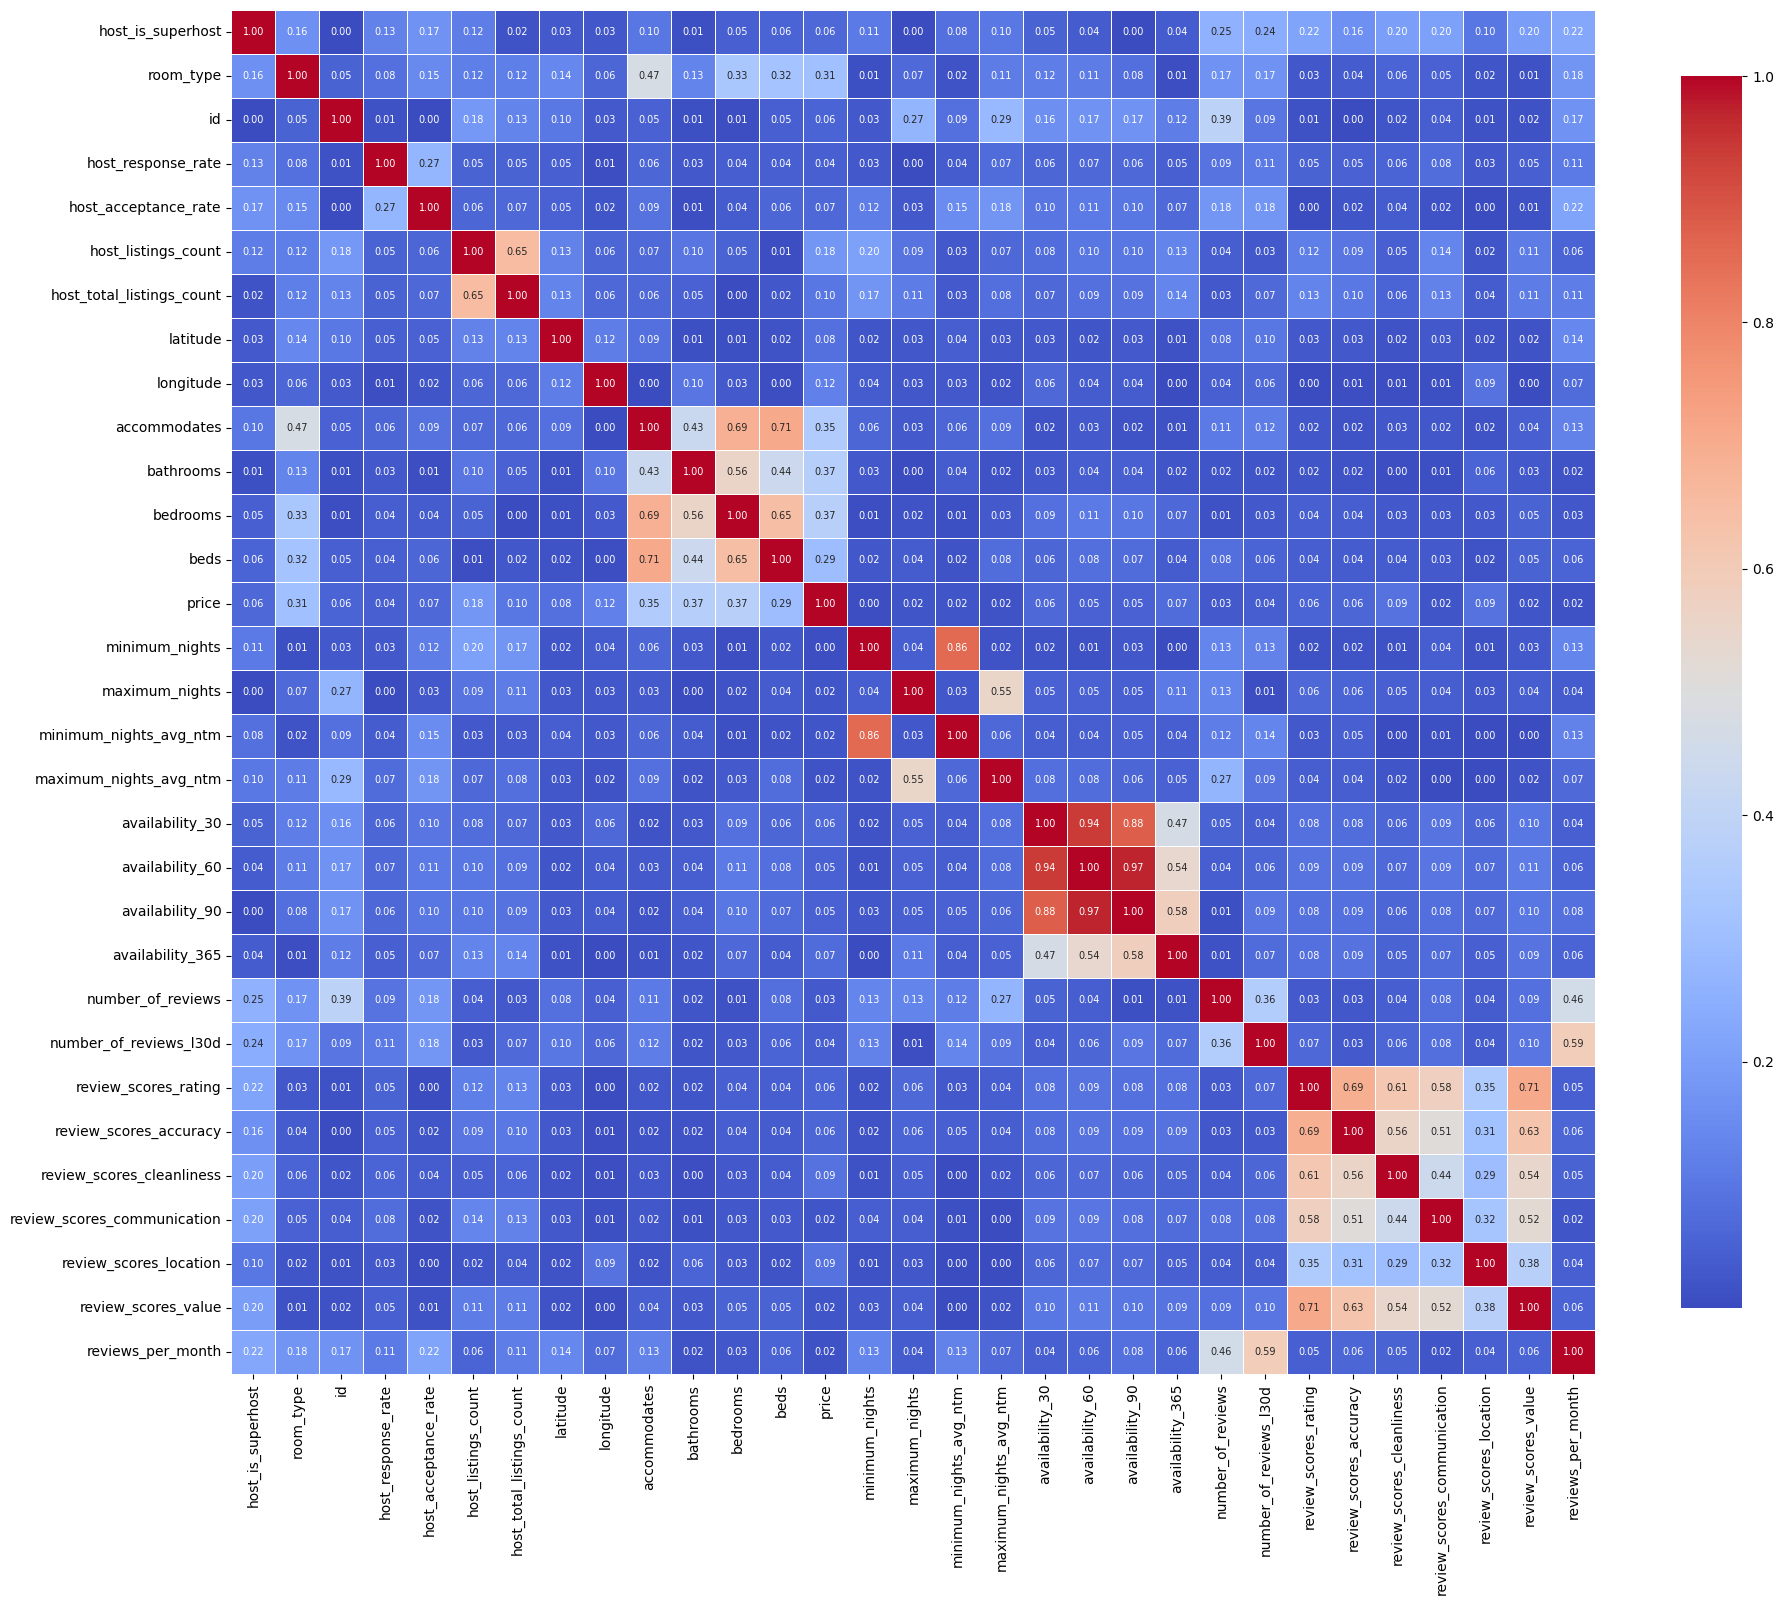

In [14]:
# Ajustar el tamaño de la figura
plt.figure(figsize=(22, 20))

# Crear una máscara para la mitad superior (opcional, si quieres ver solo la parte baja)
mask = np.triu(np.ones_like(corr_Factors1, dtype=bool))

# Crear el mapa de calor con mejoras
heat_map = sns.heatmap(
    corr_Factors1, 
    cmap="coolwarm",   # Mejora la diferenciación entre positivos y negativos
    annot=True, 
    fmt=".2f", 
    linewidths=0.5, 
    square=True,       
    annot_kws={"size": 7},  # Reducimos el tamaño de los números internos
    cbar_kws={"shrink": 0.8}  # Hacemos la barra de colores más compacta
)

# Mejoramos la visibilidad de etiquetas
plt.xticks(rotation=90)  # Rota nombres en X para que no se encimen
plt.yticks(rotation=0)   # Mantiene etiquetas en Y horizontales

# Mostrar el gráfico
plt.show()



In [15]:
mejores_variables = {}

for var in variables:
    # Obtener las correlaciones de la variable actual con las demás, excluyéndose a sí misma
    corr_var = corr_Factors1[var].drop(var).sort_values(ascending=False)
    
    # Filtrar solo las variables que están en la lista de variables de interés
    filtered_vars = [(v, corr_var[v]) for v in corr_var.index if v in variables]
    
    # Tomar las tres variables con mayor correlación
    mejores_variables[var] = filtered_vars[:3]

# Convertir el diccionario en una lista de filas para el DataFrame
tabla_corr = []

for var, correlaciones in mejores_variables.items():
    for i, (var_correlacionada, valor_corr) in enumerate(correlaciones, start=1):
        tabla_corr.append([var, f"Var_{i}", var_correlacionada, valor_corr])

# Crear el DataFrame con columnas organizadas
df_corr = pd.DataFrame(tabla_corr, columns=["Variable", "Ranking", "Variable Correlacionada", "Valor Correlación"])

# Formatear la salida para mejor visualización
df_corr = df_corr.pivot(index="Variable", columns="Ranking", values=["Variable Correlacionada", "Valor Correlación"])

# Ordenar las variables para mayor claridad
df_corr = df_corr.sort_index()

# Mostrar la tabla
df_corr



Variable Correlacionada                             \
Ranking                                     Var_1                      Var_2   
Variable                                                                       
accommodates                             bedrooms                  room_type   
bedrooms                             accommodates                      price   
host_acceptance_rate            reviews_per_month          host_is_superhost   
host_is_superhost               reviews_per_month        review_scores_value   
host_total_listings_count                      id                  room_type   
id                              reviews_per_month  host_total_listings_count   
price                                    bedrooms               accommodates   
review_scores_value             host_is_superhost  host_total_listings_count   
reviews_per_month               host_is_superhost       host_acceptance_rate   
room_type                            accommodates                   bedrooms   

                                                Valor Correlación            \
Ranking                                   Var_3             Var_1     Var_2   
Variable                                                                      
accommodates                              price          0.689525  0.474013   
bedrooms                              room_type          0.689525  0.371379   
host_acceptance_rate                  room_type          0.216869  0.171272   
host_is_superhost          host_acceptance_rate           0.22424  0.196923   
host_total_listings_count     reviews_per_month          0.131743  0.120456   
id                                        price           0.16887  0.131743   
price                                 room_type          0.371379  0.353302   
review_scores_value           reviews_per_month          0.196923  0.111994   
reviews_per_month                     room_type           0.22424  0.216869   
room_type                                 price          0.474013  0.332005   

                                     
Ranking                       Var_3  
Variable                             
accommodates               0.353302  
bedrooms                   0.332005  
host_acceptance_rate       0.147463  
host_is_superhost          0.171272  
host_total_listings_count  0.114183  
id                         0.057512  
price                      0.308076  
review_scores_value        0.056307  
reviews_per_month          0.175502  
room_type                  0.308076

# **Variable 1: id**

**Lineal Simple**

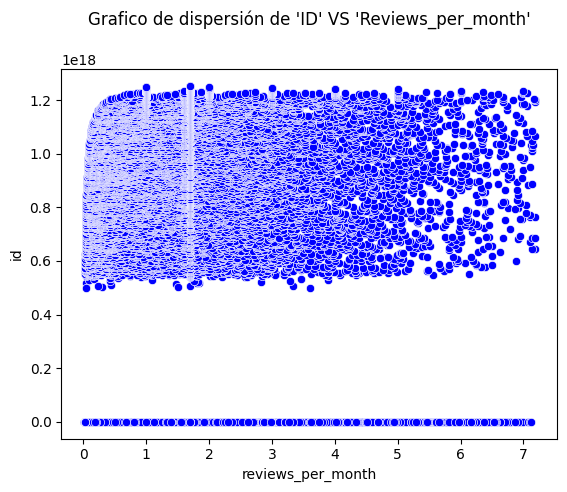

In [16]:
#Imprimimos el scater plot entre la variable dependiente e independiente 
#para observar el comportamiento en su dispersión

#(id vs reviews_per_month)
sns.scatterplot(x='reviews_per_month', y='id', color="blue", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión de 'ID' VS 'Reviews_per_month'\n")

# Mostrar la gráfica
plt.show()

In [17]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['reviews_per_month']]
Var_Dep= df['id']

In [18]:
model= LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [19]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

LinearRegression()

In [20]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['reviews_per_month'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([6.10281476e+16]),
 'rank_': 1,
 'singular_': array([220.56774398]),
 'intercept_': np.float64(4.329073955059255e+17)}

In [21]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.028516925517973912

In [22]:
#Predecimos los valores mediante 3 variables
y_pred= model.predict(X=df[['reviews_per_month']])
y_pred

array([5.36655246e+17, 4.57928936e+17, 4.51826121e+17, ...,
       5.36655246e+17, 5.36655246e+17, 5.36655246e+17], shape=(26582,))

In [23]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(31, 'Predicciones_id_simple', y_pred)
df  

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,number_of_reviews,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,Predicciones_id_simple
0,0,0,35797,1.00,1.00,1.0,1.0,19.383820,-99.200000,2.0,...,0.0,0.0,4.80,4.90,4.80,4.80,4.80,4.70,1.70,5.366552e+17
1,1,0,44616,1.00,0.93,12.0,13.0,19.411620,-99.177940,3.1,...,64.0,0.0,4.58,4.56,4.70,4.78,4.98,4.48,0.41,4.579289e+17
2,1,0,67703,0.71,0.57,3.0,4.0,19.411520,-99.168570,4.0,...,49.0,0.0,4.90,4.81,4.75,4.92,4.98,4.91,0.31,4.518261e+17
3,1,0,70644,1.00,1.00,3.0,4.0,19.356140,-99.163080,2.0,...,127.0,2.0,4.91,4.90,4.96,4.98,4.96,4.92,0.83,4.835608e+17
4,1,0,107078,1.00,1.00,5.0,7.0,19.432110,-99.193270,2.0,...,11.0,0.0,4.91,5.00,5.00,4.73,4.91,4.82,0.11,4.396205e+17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26577,1,2,1252141718111439700,1.00,1.00,167.0,279.0,19.387329,-99.246731,4.0,...,0.0,0.0,4.80,4.90,4.80,4.80,4.80,4.70,1.70,5.366552e+17
26578,0,2,1252159821531694005,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,0.0,0.0,4.80,4.90,4.80,4.80,4.80,4.70,1.70,5.366552e+17
26579,0,2,1252185591721328995,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,0.0,0.0,4.80,4.90,4.80,4.80,4.80,4.70,1.70,5.366552e+17
26580,0,2,1252218347521498445,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,0.0,0.0,4.80,4.90,4.80,4.80,4.80,4.70,1.70,5.366552e+17


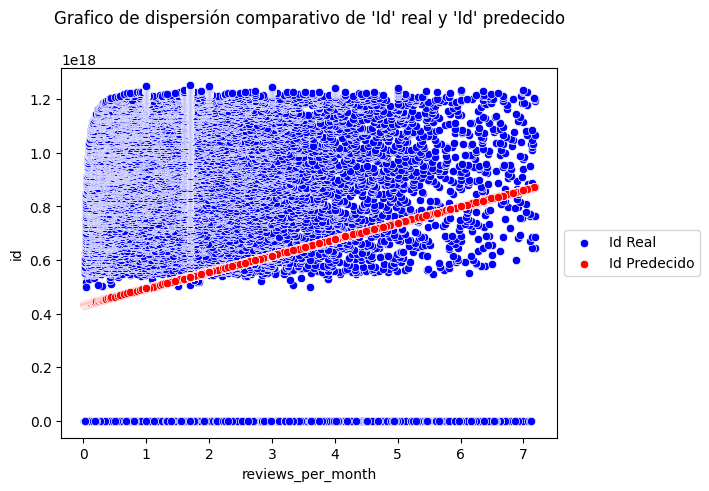

In [24]:
sns.scatterplot(x='reviews_per_month', y='id', color="blue", data=df)
sns.scatterplot(x='reviews_per_month', y='Predicciones_id_simple', color="red", data=df)
#sns.lineplot(x='Reviews_per_month', y='Predicciones_id_simple', color="red", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión comparativo de 'Id' real y 'Id' predecido\n")

# Agregar la leyenda manualmente
plt.legend(labels=["Id Real", "Id Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [25]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
resultados[("Lineal Simple","Prediccion_id","determinacion")] = coef_Deter
coef_Deter

0.028516925517973912

In [26]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
resultados[("Lineal Simple","Prediccion_id","correlacion")] = coef_Correl
coef_Correl

np.float64(0.16886955177880325)

**Lineal Múltiple**

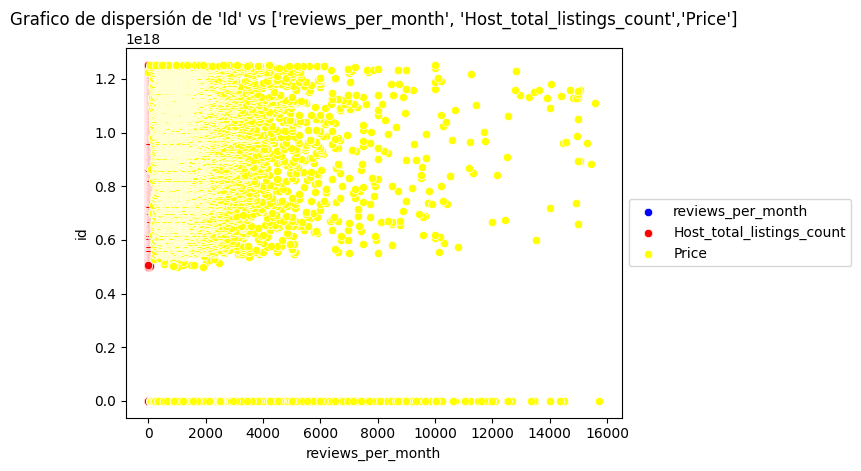

In [27]:
#Imprimimos el scater plot entre la variable dependiente e independientes 
#para observar el comportamiento en su dispersión

#(id vs [reviews_per_month, host_total_listings_count, price])
sns.scatterplot(x='reviews_per_month', y='id', color="blue", data=df)
sns.scatterplot(x='host_total_listings_count', y='id', color="red", data=df)
sns.scatterplot(x='price', y='id', color="yellow", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión de 'Id' vs ['reviews_per_month', 'Host_total_listings_count','Price']")

# Agregar la leyenda manualmente
plt.legend(labels=["reviews_per_month", "Host_total_listings_count", "Price"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [28]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['reviews_per_month', 'host_total_listings_count','price']]
Var_Dep= df['id']

In [29]:
model= LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [30]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

LinearRegression()

In [31]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['reviews_per_month', 'host_total_listings_count', 'price'],
       dtype=object),
 'n_features_in_': 3,
 'coef_': array([5.68143310e+16, 1.00703427e+15, 1.81196204e+13]),
 'rank_': 3,
 'singular_': array([215042.02334552,   8568.03528845,    219.04072325]),
 'intercept_': np.float64(3.932942524108024e+17)}

In [32]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.0436943663577356

In [33]:
#Predecimos los valores mediante 3 variables
y_pred= model.predict(X=df[['reviews_per_month', 'host_total_listings_count','price']])
y_pred

array([5.60917982e+17, 4.51785510e+17, 4.51699542e+17, ...,
       5.54914138e+17, 5.53102176e+17, 5.20436667e+17], shape=(26582,))

In [34]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(32, 'Predicciones_id_multiple', y_pred)
df  

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,Predicciones_id_simple,Predicciones_id_multiple
0,0,0,35797,1.00,1.00,1.0,1.0,19.383820,-99.200000,2.0,...,0.0,4.80,4.90,4.80,4.80,4.80,4.70,1.70,5.366552e+17,5.609180e+17
1,1,0,44616,1.00,0.93,12.0,13.0,19.411620,-99.177940,3.1,...,0.0,4.58,4.56,4.70,4.78,4.98,4.48,0.41,4.579289e+17,4.517855e+17
2,1,0,67703,0.71,0.57,3.0,4.0,19.411520,-99.168570,4.0,...,0.0,4.90,4.81,4.75,4.92,4.98,4.91,0.31,4.518261e+17,4.516995e+17
3,1,0,70644,1.00,1.00,3.0,4.0,19.356140,-99.163080,2.0,...,2.0,4.91,4.90,4.96,4.98,4.96,4.92,0.83,4.835608e+17,4.651347e+17
4,1,0,107078,1.00,1.00,5.0,7.0,19.432110,-99.193270,2.0,...,0.0,4.91,5.00,5.00,4.73,4.91,4.82,0.11,4.396205e+17,4.724216e+17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26577,1,2,1252141718111439700,1.00,1.00,167.0,279.0,19.387329,-99.246731,4.0,...,0.0,4.80,4.90,4.80,4.80,4.80,4.70,1.70,5.366552e+17,7.796836e+17
26578,0,2,1252159821531694005,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,0.0,4.80,4.90,4.80,4.80,4.80,4.70,1.70,5.366552e+17,5.567261e+17
26579,0,2,1252185591721328995,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,0.0,4.80,4.90,4.80,4.80,4.80,4.70,1.70,5.366552e+17,5.549141e+17
26580,0,2,1252218347521498445,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,0.0,4.80,4.90,4.80,4.80,4.80,4.70,1.70,5.366552e+17,5.531022e+17


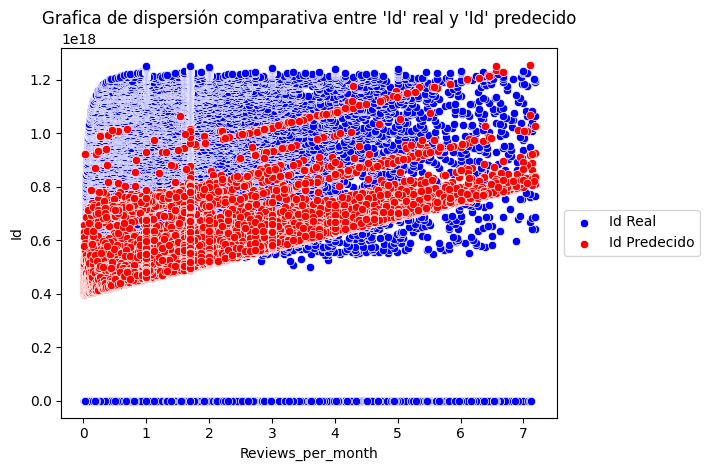

In [35]:
sns.scatterplot(x='reviews_per_month', y='id', color="blue", data=df)
sns.scatterplot(x='reviews_per_month', y='Predicciones_id_multiple', color="red", data=df)
#sns.lineplot(x='reviews_per_month', y='Predicciones_id_multiple', color="red", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafica de dispersión comparativa entre 'Id' real y 'Id' predecido")
plt.xlabel("Reviews_per_month")
plt.ylabel("Id")

# Agregar la leyenda manualmente
plt.legend(labels=["Id Real", "Id Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [36]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
resultados[("Lineal Multiple","Prediccion_id","determinacion")] = coef_Deter
coef_Deter

0.0436943663577356

In [37]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
resultados[("Lineal Multiple","Prediccion_id","correlacion")] = coef_Correl
coef_Correl

np.float64(0.20903197448652588)

# **Variable 2: host_acceptance_rate**

**Lineal Simple**

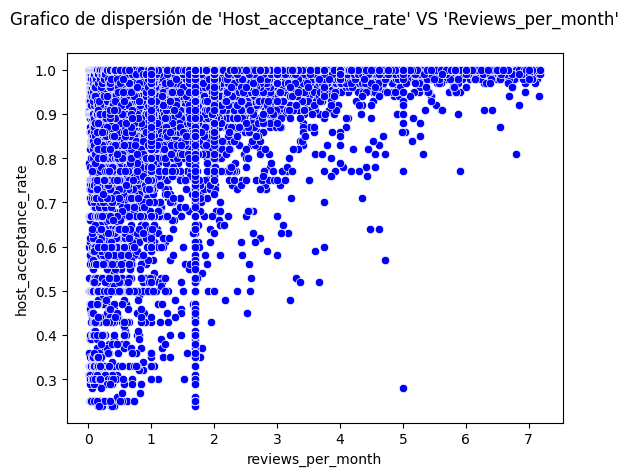

In [38]:
#Imprimimos el scater plot entre la variable dependiente e independiente 
#para observar el comportamiento en su dispersión

#(host_acceptance_rate vs reviews_per_month)
sns.scatterplot(x='reviews_per_month', y='host_acceptance_rate', color="blue", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión de 'Host_acceptance_rate' VS 'Reviews_per_month'\n")

# Mostrar la gráfica
plt.show()

In [39]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['reviews_per_month']]
Var_Dep= df['host_acceptance_rate']

In [40]:
model= LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [41]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

LinearRegression()

In [42]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['reviews_per_month'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.02082553]),
 'rank_': 1,
 'singular_': array([220.56774398]),
 'intercept_': np.float64(0.9091430250571527)}

In [43]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.04703228996599196

In [44]:
#Predecimos los valores mediante 3 variables
y_pred= model.predict(X=df[['reviews_per_month']])
y_pred

array([0.94454642, 0.91768149, 0.91559894, ..., 0.94454642, 0.94454642,
       0.94454642], shape=(26582,))

In [45]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(33, 'Predicciones_host_acceptance_rate_simple', y_pred)
df

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,Predicciones_id_simple,Predicciones_id_multiple,Predicciones_host_acceptance_rate_simple
0,0,0,35797,1.00,1.00,1.0,1.0,19.383820,-99.200000,2.0,...,4.80,4.90,4.80,4.80,4.80,4.70,1.70,5.366552e+17,5.609180e+17,0.944546
1,1,0,44616,1.00,0.93,12.0,13.0,19.411620,-99.177940,3.1,...,4.58,4.56,4.70,4.78,4.98,4.48,0.41,4.579289e+17,4.517855e+17,0.917681
2,1,0,67703,0.71,0.57,3.0,4.0,19.411520,-99.168570,4.0,...,4.90,4.81,4.75,4.92,4.98,4.91,0.31,4.518261e+17,4.516995e+17,0.915599
3,1,0,70644,1.00,1.00,3.0,4.0,19.356140,-99.163080,2.0,...,4.91,4.90,4.96,4.98,4.96,4.92,0.83,4.835608e+17,4.651347e+17,0.926428
4,1,0,107078,1.00,1.00,5.0,7.0,19.432110,-99.193270,2.0,...,4.91,5.00,5.00,4.73,4.91,4.82,0.11,4.396205e+17,4.724216e+17,0.911434
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26577,1,2,1252141718111439700,1.00,1.00,167.0,279.0,19.387329,-99.246731,4.0,...,4.80,4.90,4.80,4.80,4.80,4.70,1.70,5.366552e+17,7.796836e+17,0.944546
26578,0,2,1252159821531694005,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,4.80,4.90,4.80,4.80,4.80,4.70,1.70,5.366552e+17,5.567261e+17,0.944546
26579,0,2,1252185591721328995,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,4.80,4.90,4.80,4.80,4.80,4.70,1.70,5.366552e+17,5.549141e+17,0.944546
26580,0,2,1252218347521498445,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,4.80,4.90,4.80,4.80,4.80,4.70,1.70,5.366552e+17,5.531022e+17,0.944546


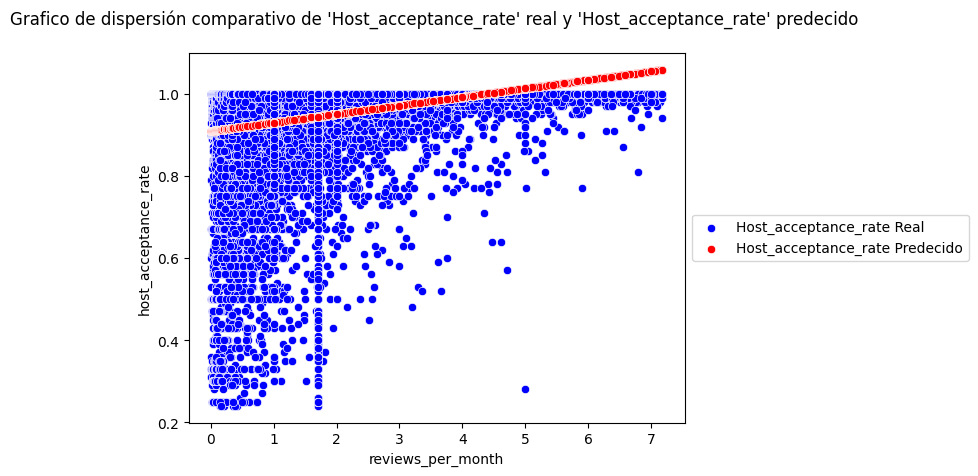

In [46]:
sns.scatterplot(x='reviews_per_month', y='host_acceptance_rate', color="blue", data=df)
sns.scatterplot(x='reviews_per_month', y='Predicciones_host_acceptance_rate_simple', color="red", data=df)
#sns.lineplot(x='reviews_per_month', y='Predicciones_host_acceptance_rate_simple', color="red", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión comparativo de 'Host_acceptance_rate' real y 'Host_acceptance_rate' predecido \n")

# Agregar la leyenda manualmente
plt.legend(labels=["Host_acceptance_rate Real", "Host_acceptance_rate Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [47]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
resultados[("Lineal Simple","Prediccion_host_acceptance_rate","determinacion")] = coef_Deter
coef_Deter

0.04703228996599196

In [48]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
resultados[("Lineal Simple","Prediccion_host_acceptance_rate","correlacion")] = coef_Correl
coef_Correl

np.float64(0.2168692923536939)

**Lineal Múltiple**

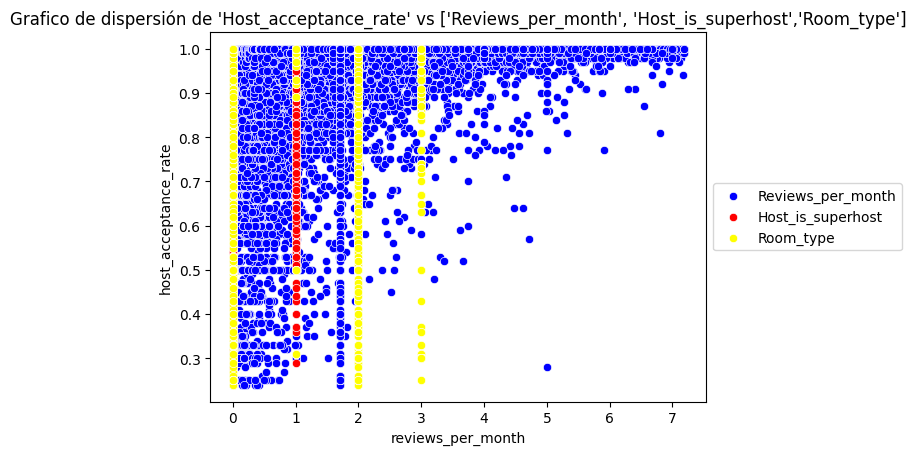

In [49]:
#Imprimimos el scater plot entre la variable dependiente e independientes 
#para observar el comportamiento en su dispersión

#(host_acceptance_rate vs [reviews_per_month, host_is_superhost, room_type])
sns.scatterplot(x='reviews_per_month', y='host_acceptance_rate', color="blue", data=df)
sns.scatterplot(x='host_is_superhost', y='host_acceptance_rate', color="red", data=df)
sns.scatterplot(x='room_type', y='host_acceptance_rate', color="yellow", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión de 'Host_acceptance_rate' vs ['Reviews_per_month', 'Host_is_superhost','Room_type']")

# Agregar la leyenda manualmente
plt.legend(labels=["Reviews_per_month", "Host_is_superhost", "Room_type"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [50]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['reviews_per_month', 'host_is_superhost', 'room_type']]
Var_Dep= df['host_acceptance_rate']

In [51]:
model= LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [52]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

LinearRegression()

In [53]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['reviews_per_month', 'host_is_superhost', 'room_type'],
       dtype=object),
 'n_features_in_': 3,
 'coef_': array([ 0.01666497,  0.03140158, -0.013056  ]),
 'rank_': 3,
 'singular_': array([224.91430971, 154.47222496,  75.50378427]),
 'intercept_': np.float64(0.9135193335562232)}

In [54]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.07204464270784039

In [55]:
#Predecimos los valores mediante 3 variables
y_pred= model.predict(X=df[['reviews_per_month', 'host_is_superhost', 'room_type']])
y_pred

array([0.94184978, 0.95175355, 0.95008705, ..., 0.91573777, 0.91573777,
       0.97325135], shape=(26582,))

In [56]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(34, 'Predicciones_host_acceptance_rate_multiple', y_pred)
df

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,review_scores_accuracy,review_scores_cleanliness,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,Predicciones_id_simple,Predicciones_id_multiple,Predicciones_host_acceptance_rate_simple,Predicciones_host_acceptance_rate_multiple
0,0,0,35797,1.00,1.00,1.0,1.0,19.383820,-99.200000,2.0,...,4.90,4.80,4.80,4.80,4.70,1.70,5.366552e+17,5.609180e+17,0.944546,0.941850
1,1,0,44616,1.00,0.93,12.0,13.0,19.411620,-99.177940,3.1,...,4.56,4.70,4.78,4.98,4.48,0.41,4.579289e+17,4.517855e+17,0.917681,0.951754
2,1,0,67703,0.71,0.57,3.0,4.0,19.411520,-99.168570,4.0,...,4.81,4.75,4.92,4.98,4.91,0.31,4.518261e+17,4.516995e+17,0.915599,0.950087
3,1,0,70644,1.00,1.00,3.0,4.0,19.356140,-99.163080,2.0,...,4.90,4.96,4.98,4.96,4.92,0.83,4.835608e+17,4.651347e+17,0.926428,0.958753
4,1,0,107078,1.00,1.00,5.0,7.0,19.432110,-99.193270,2.0,...,5.00,5.00,4.73,4.91,4.82,0.11,4.396205e+17,4.724216e+17,0.911434,0.946754
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26577,1,2,1252141718111439700,1.00,1.00,167.0,279.0,19.387329,-99.246731,4.0,...,4.90,4.80,4.80,4.80,4.70,1.70,5.366552e+17,7.796836e+17,0.944546,0.947139
26578,0,2,1252159821531694005,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,4.90,4.80,4.80,4.80,4.70,1.70,5.366552e+17,5.567261e+17,0.944546,0.915738
26579,0,2,1252185591721328995,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,4.90,4.80,4.80,4.80,4.70,1.70,5.366552e+17,5.549141e+17,0.944546,0.915738
26580,0,2,1252218347521498445,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,4.90,4.80,4.80,4.80,4.70,1.70,5.366552e+17,5.531022e+17,0.944546,0.915738


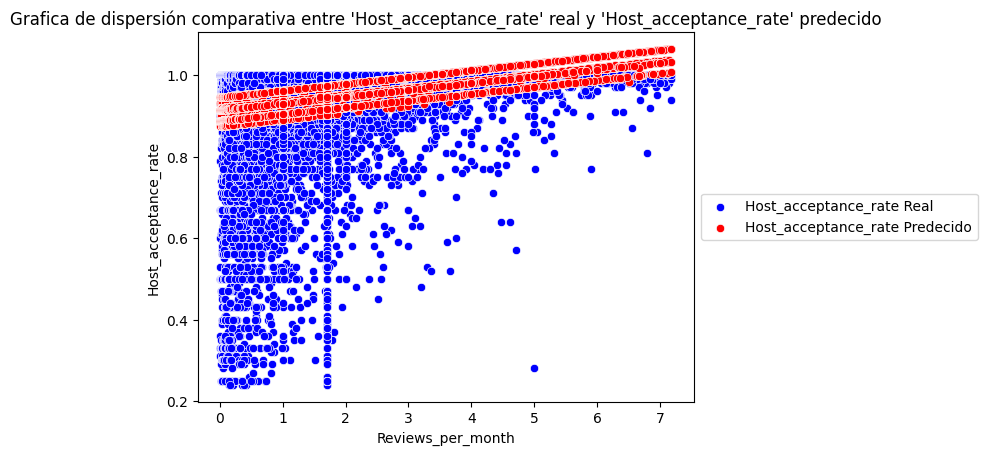

In [57]:
sns.scatterplot(x='reviews_per_month', y='host_acceptance_rate', color="blue", data=df)
sns.scatterplot(x='reviews_per_month', y='Predicciones_host_acceptance_rate_multiple', color="red", data=df)
#sns.lineplot(x='reviews_per_month', y='Predicciones_host_acceptance_rate_multiple', color="red", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafica de dispersión comparativa entre 'Host_acceptance_rate' real y 'Host_acceptance_rate' predecido")
plt.xlabel("Reviews_per_month")
plt.ylabel("Host_acceptance_rate")

# Agregar la leyenda manualmente
plt.legend(labels=["Host_acceptance_rate Real", "Host_acceptance_rate Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [58]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
resultados[("Lineal Multiple","Prediccion_host_acceptance_rate","determinacion")] = coef_Deter
coef_Deter

0.07204464270784039

In [59]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
resultados[("Lineal Multiple","Prediccion_host_acceptance_rate","correlacion")] = coef_Correl
coef_Correl

np.float64(0.26841133118376426)

# **Variable 3: host_is_superhost**

**Lineal Simple**

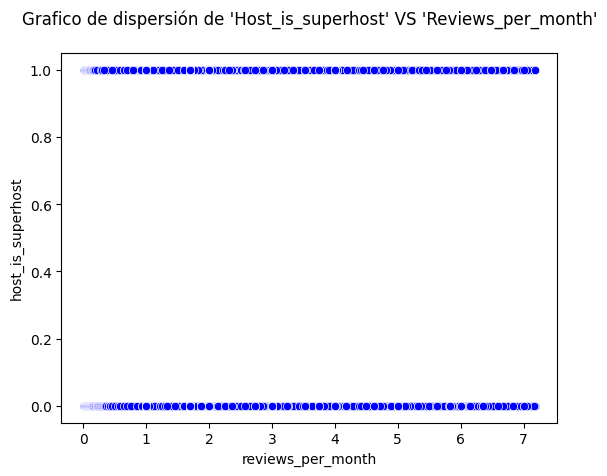

In [60]:
#Imprimimos el scater plot entre la variable dependiente e independiente 
#para observar el comportamiento en su dispersión

#(host_is_superhost vs reviews_per_month)
sns.scatterplot(x='reviews_per_month', y='host_is_superhost', color="blue", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión de 'Host_is_superhost' VS 'Reviews_per_month'\n")

# Mostrar la gráfica
plt.show()

In [61]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['reviews_per_month']]
Var_Dep= df['host_is_superhost']

In [62]:
model= LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [63]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

LinearRegression()

In [64]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['reviews_per_month'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.0798418]),
 'rank_': 1,
 'singular_': array([220.56774398]),
 'intercept_': np.float64(0.23782327671085635)}

In [65]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.05028339687977046

In [66]:
#Predecimos los valores mediante 3 variables
y_pred= model.predict(X=df[['reviews_per_month']])
y_pred

array([0.37355433, 0.27055841, 0.26257423, ..., 0.37355433, 0.37355433,
       0.37355433], shape=(26582,))

In [67]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(35, 'Predicciones_host_is_superhost_simple', y_pred)
df

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,review_scores_cleanliness,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,Predicciones_id_simple,Predicciones_id_multiple,Predicciones_host_acceptance_rate_simple,Predicciones_host_acceptance_rate_multiple,Predicciones_host_is_superhost_simple
0,0,0,35797,1.00,1.00,1.0,1.0,19.383820,-99.200000,2.0,...,4.80,4.80,4.80,4.70,1.70,5.366552e+17,5.609180e+17,0.944546,0.941850,0.373554
1,1,0,44616,1.00,0.93,12.0,13.0,19.411620,-99.177940,3.1,...,4.70,4.78,4.98,4.48,0.41,4.579289e+17,4.517855e+17,0.917681,0.951754,0.270558
2,1,0,67703,0.71,0.57,3.0,4.0,19.411520,-99.168570,4.0,...,4.75,4.92,4.98,4.91,0.31,4.518261e+17,4.516995e+17,0.915599,0.950087,0.262574
3,1,0,70644,1.00,1.00,3.0,4.0,19.356140,-99.163080,2.0,...,4.96,4.98,4.96,4.92,0.83,4.835608e+17,4.651347e+17,0.926428,0.958753,0.304092
4,1,0,107078,1.00,1.00,5.0,7.0,19.432110,-99.193270,2.0,...,5.00,4.73,4.91,4.82,0.11,4.396205e+17,4.724216e+17,0.911434,0.946754,0.246606
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26577,1,2,1252141718111439700,1.00,1.00,167.0,279.0,19.387329,-99.246731,4.0,...,4.80,4.80,4.80,4.70,1.70,5.366552e+17,7.796836e+17,0.944546,0.947139,0.373554
26578,0,2,1252159821531694005,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,4.80,4.80,4.80,4.70,1.70,5.366552e+17,5.567261e+17,0.944546,0.915738,0.373554
26579,0,2,1252185591721328995,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,4.80,4.80,4.80,4.70,1.70,5.366552e+17,5.549141e+17,0.944546,0.915738,0.373554
26580,0,2,1252218347521498445,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,4.80,4.80,4.80,4.70,1.70,5.366552e+17,5.531022e+17,0.944546,0.915738,0.373554


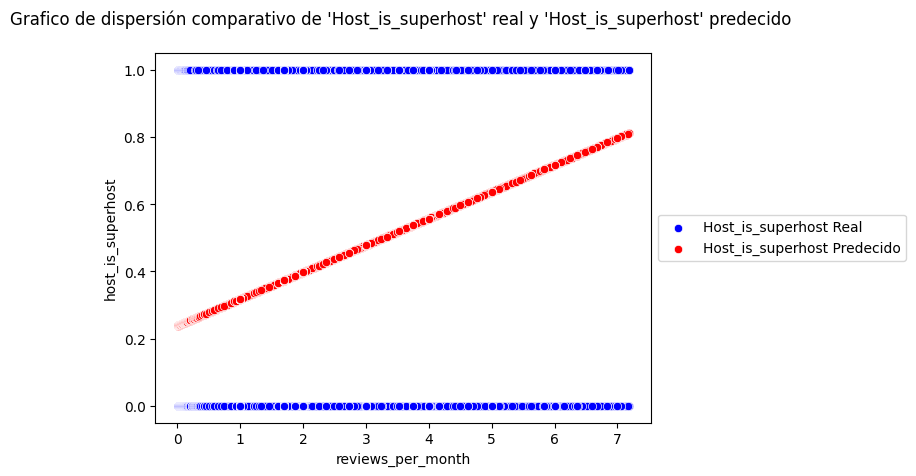

In [68]:
sns.scatterplot(x='reviews_per_month', y='host_is_superhost', color="blue", data=df)
sns.scatterplot(x='reviews_per_month', y='Predicciones_host_is_superhost_simple', color="red", data=df)
#sns.lineplot(x='reviews_per_month', y='Predicciones_host_is_superhost_simple', color="red", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión comparativo de 'Host_is_superhost' real y 'Host_is_superhost' predecido \n")

# Agregar la leyenda manualmente
plt.legend(labels=["Host_is_superhost Real", "Host_is_superhost Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [69]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
resultados[("Lineal Simple","Prediccion_host_is_superhost","determinacion")] = coef_Deter
coef_Deter

0.05028339687977046

In [70]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
resultados[("Lineal Simple","Prediccion_host_is_superhost","correlacion")] = coef_Correl
coef_Correl

np.float64(0.22423959703801302)

**Lineal Múltiple**

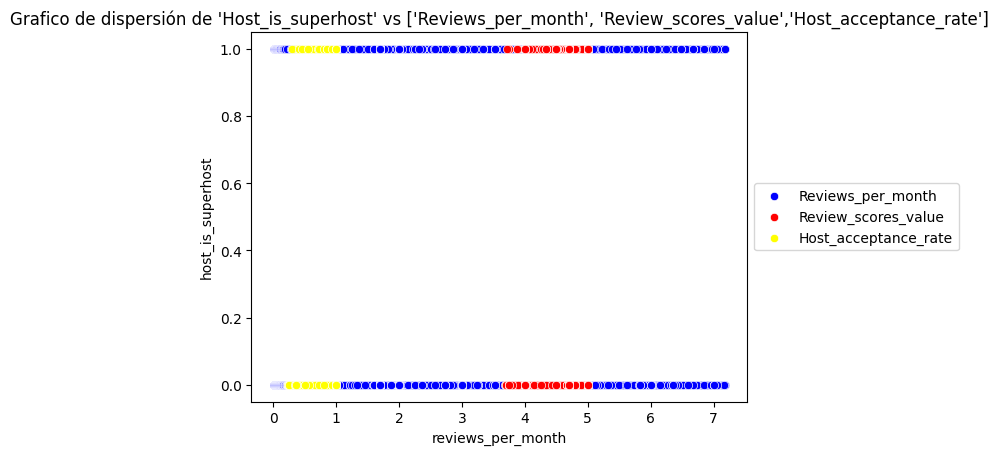

In [71]:
#Imprimimos el scater plot entre la variable dependiente e independientes 
#para observar el comportamiento en su dispersión

#(host_is_superhost vs [reviews_per_month, review_scores_value, host_acceptance_rate])
sns.scatterplot(x='reviews_per_month', y='host_is_superhost', color="blue", data=df)
sns.scatterplot(x='review_scores_value', y='host_is_superhost', color="red", data=df)
sns.scatterplot(x='host_acceptance_rate', y='host_is_superhost', color="yellow", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión de 'Host_is_superhost' vs ['Reviews_per_month', 'Review_scores_value','Host_acceptance_rate']")

# Agregar la leyenda manualmente
plt.legend(labels=["Reviews_per_month", "Review_scores_value", "Host_acceptance_rate"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [72]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['reviews_per_month', 'review_scores_value', 'host_acceptance_rate']]
Var_Dep= df['host_is_superhost']

In [73]:
model= LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [74]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

LinearRegression()

In [75]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['reviews_per_month', 'review_scores_value', 'host_acceptance_rate'],
       dtype=object),
 'n_features_in_': 3,
 'coef_': array([0.0662039 , 0.42051121, 0.47692517]),
 'rank_': 3,
 'singular_': array([220.62476959,  34.46406827,  20.67207059]),
 'intercept_': np.float64(-2.1899972844111284)}

In [76]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.10012324438473741

In [77]:
#Predecimos los valores mediante 3 variables
y_pred= model.predict(X=df[['reviews_per_month', 'review_scores_value', 'host_acceptance_rate']])
y_pred

array([0.37587719, 0.16457693, 0.16708329, ..., 0.37587719, 0.37587719,
       0.37587719], shape=(26582,))

In [78]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(36, 'Predicciones_host_is_superhost_multiple', y_pred)
df

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,Predicciones_id_simple,Predicciones_id_multiple,Predicciones_host_acceptance_rate_simple,Predicciones_host_acceptance_rate_multiple,Predicciones_host_is_superhost_simple,Predicciones_host_is_superhost_multiple
0,0,0,35797,1.00,1.00,1.0,1.0,19.383820,-99.200000,2.0,...,4.80,4.80,4.70,1.70,5.366552e+17,5.609180e+17,0.944546,0.941850,0.373554,0.375877
1,1,0,44616,1.00,0.93,12.0,13.0,19.411620,-99.177940,3.1,...,4.78,4.98,4.48,0.41,4.579289e+17,4.517855e+17,0.917681,0.951754,0.270558,0.164577
2,1,0,67703,0.71,0.57,3.0,4.0,19.411520,-99.168570,4.0,...,4.92,4.98,4.91,0.31,4.518261e+17,4.516995e+17,0.915599,0.950087,0.262574,0.167083
3,1,0,70644,1.00,1.00,3.0,4.0,19.356140,-99.163080,2.0,...,4.98,4.96,4.92,0.83,4.835608e+17,4.651347e+17,0.926428,0.958753,0.304092,0.410792
4,1,0,107078,1.00,1.00,5.0,7.0,19.432110,-99.193270,2.0,...,4.73,4.91,4.82,0.11,4.396205e+17,4.724216e+17,0.911434,0.946754,0.246606,0.321074
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26577,1,2,1252141718111439700,1.00,1.00,167.0,279.0,19.387329,-99.246731,4.0,...,4.80,4.80,4.70,1.70,5.366552e+17,7.796836e+17,0.944546,0.947139,0.373554,0.375877
26578,0,2,1252159821531694005,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,4.80,4.80,4.70,1.70,5.366552e+17,5.567261e+17,0.944546,0.915738,0.373554,0.375877
26579,0,2,1252185591721328995,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,4.80,4.80,4.70,1.70,5.366552e+17,5.549141e+17,0.944546,0.915738,0.373554,0.375877
26580,0,2,1252218347521498445,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,4.80,4.80,4.70,1.70,5.366552e+17,5.531022e+17,0.944546,0.915738,0.373554,0.375877


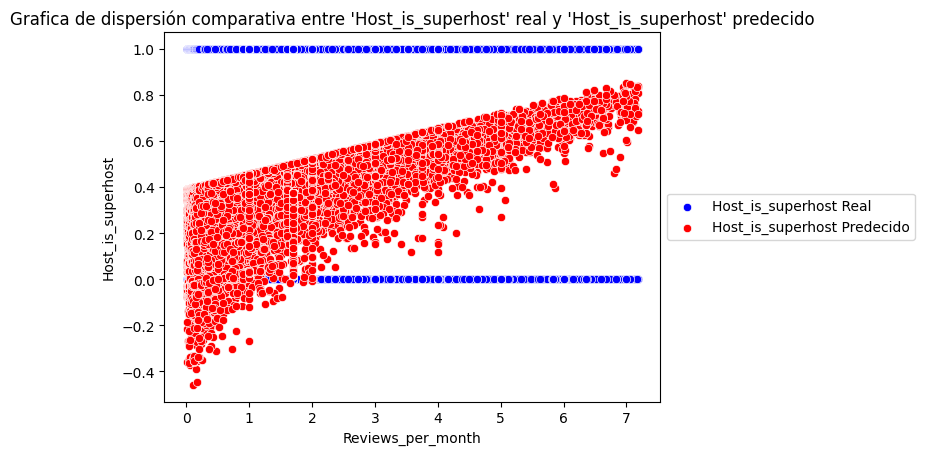

In [79]:
sns.scatterplot(x='reviews_per_month', y='host_is_superhost', color="blue", data=df)
sns.scatterplot(x='reviews_per_month', y='Predicciones_host_is_superhost_multiple', color="red", data=df)
#sns.lineplot(x='reviews_per_month', y='Predicciones_host_is_superhost_multiple', color="red", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafica de dispersión comparativa entre 'Host_is_superhost' real y 'Host_is_superhost' predecido")
plt.xlabel("Reviews_per_month")
plt.ylabel("Host_is_superhost")

# Agregar la leyenda manualmente
plt.legend(labels=["Host_is_superhost Real", "Host_is_superhost Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [80]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
resultados[("Lineal Multiple","Prediccion_host_is_superhost","determinacion")] = coef_Deter
coef_Deter

0.10012324438473741

In [81]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
resultados[("Lineal Multiple","Prediccion_host_is_superhost","correlacion")] = coef_Correl
coef_Correl

np.float64(0.31642257249560657)

# **Variable 4: host_total_listings_count**

**Lineal Simple**

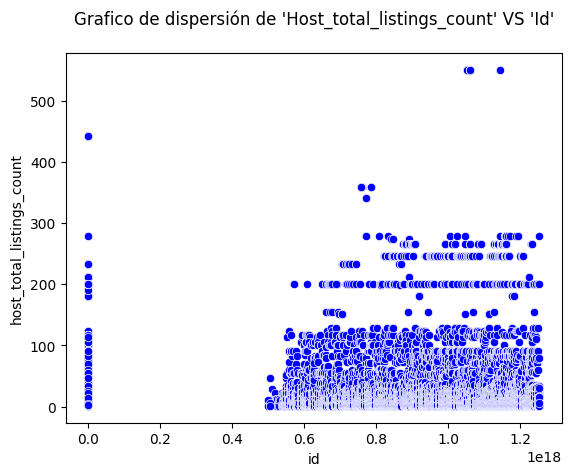

In [82]:
#Imprimimos el scater plot entre la variable dependiente e independiente 
#para observar el comportamiento en su dispersión

#(host_total_listings_count vs id)
sns.scatterplot(x='id', y='host_total_listings_count', color="blue", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión de 'Host_total_listings_count' VS 'Id'\n")

# Mostrar la gráfica
plt.show()

In [83]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['id']]
Var_Dep= df['host_total_listings_count']

In [84]:
model= LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [85]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

LinearRegression()

In [86]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['id'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([1.42350092e-17]),
 'rank_': 1,
 'singular_': array([7.97114737e+19]),
 'intercept_': np.float64(14.95836174222121)}

In [87]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.0173563081632353

In [88]:
#Predecimos los valores mediante 3 variables
y_pred= model.predict(X=df[['id']])
y_pred

array([14.95836174, 14.95836174, 14.95836174, ..., 32.78323519,
       32.78370147, 32.78385535], shape=(26582,))

In [89]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(37, 'Predicciones_host_total_listings_count_simple', y_pred)
df

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,review_scores_location,review_scores_value,reviews_per_month,Predicciones_id_simple,Predicciones_id_multiple,Predicciones_host_acceptance_rate_simple,Predicciones_host_acceptance_rate_multiple,Predicciones_host_is_superhost_simple,Predicciones_host_is_superhost_multiple,Predicciones_host_total_listings_count_simple
0,0,0,35797,1.00,1.00,1.0,1.0,19.383820,-99.200000,2.0,...,4.80,4.70,1.70,5.366552e+17,5.609180e+17,0.944546,0.941850,0.373554,0.375877,14.958362
1,1,0,44616,1.00,0.93,12.0,13.0,19.411620,-99.177940,3.1,...,4.98,4.48,0.41,4.579289e+17,4.517855e+17,0.917681,0.951754,0.270558,0.164577,14.958362
2,1,0,67703,0.71,0.57,3.0,4.0,19.411520,-99.168570,4.0,...,4.98,4.91,0.31,4.518261e+17,4.516995e+17,0.915599,0.950087,0.262574,0.167083,14.958362
3,1,0,70644,1.00,1.00,3.0,4.0,19.356140,-99.163080,2.0,...,4.96,4.92,0.83,4.835608e+17,4.651347e+17,0.926428,0.958753,0.304092,0.410792,14.958362
4,1,0,107078,1.00,1.00,5.0,7.0,19.432110,-99.193270,2.0,...,4.91,4.82,0.11,4.396205e+17,4.724216e+17,0.911434,0.946754,0.246606,0.321074,14.958362
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26577,1,2,1252141718111439700,1.00,1.00,167.0,279.0,19.387329,-99.246731,4.0,...,4.80,4.70,1.70,5.366552e+17,7.796836e+17,0.944546,0.947139,0.373554,0.375877,32.782611
26578,0,2,1252159821531694005,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,4.80,4.70,1.70,5.366552e+17,5.567261e+17,0.944546,0.915738,0.373554,0.375877,32.782868
26579,0,2,1252185591721328995,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,4.80,4.70,1.70,5.366552e+17,5.549141e+17,0.944546,0.915738,0.373554,0.375877,32.783235
26580,0,2,1252218347521498445,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,4.80,4.70,1.70,5.366552e+17,5.531022e+17,0.944546,0.915738,0.373554,0.375877,32.783701


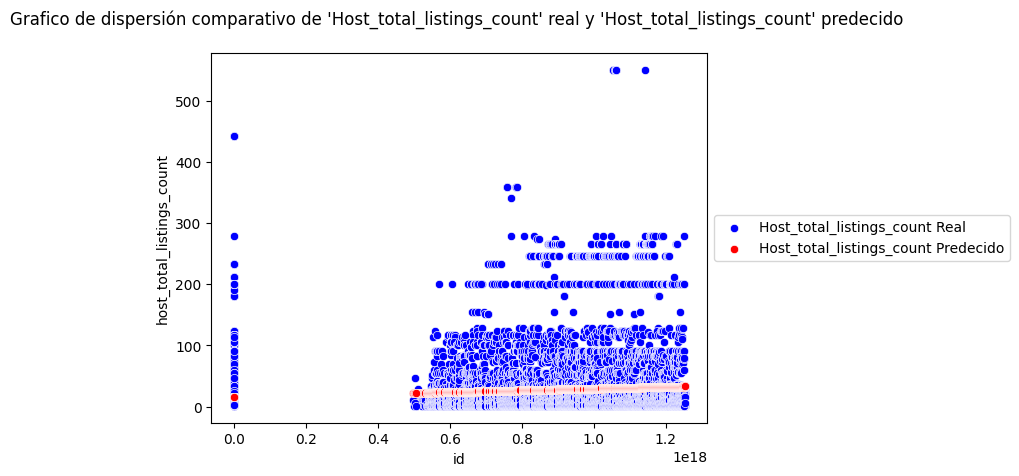

In [90]:
sns.scatterplot(x='id', y='host_total_listings_count', color="blue", data=df)
sns.scatterplot(x='id', y='Predicciones_host_total_listings_count_simple', color="red", data=df)
#sns.lineplot(x='id', y='Predicciones_host_total_listings_count_simple', color="red", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión comparativo de 'Host_total_listings_count' real y 'Host_total_listings_count' predecido \n")

# Agregar la leyenda manualmente
plt.legend(labels=["Host_total_listings_count Real", "Host_total_listings_count Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [91]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
resultados[("Lineal Simple","Prediccion_host_total_listings_count","determinacion")] = coef_Deter
coef_Deter

0.0173563081632353

In [92]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
resultados[("Lineal Simple","Prediccion_host_total_listings_count","correlacion")] = coef_Correl
coef_Correl

np.float64(0.13174334200723503)

**Lineal Múltiple**

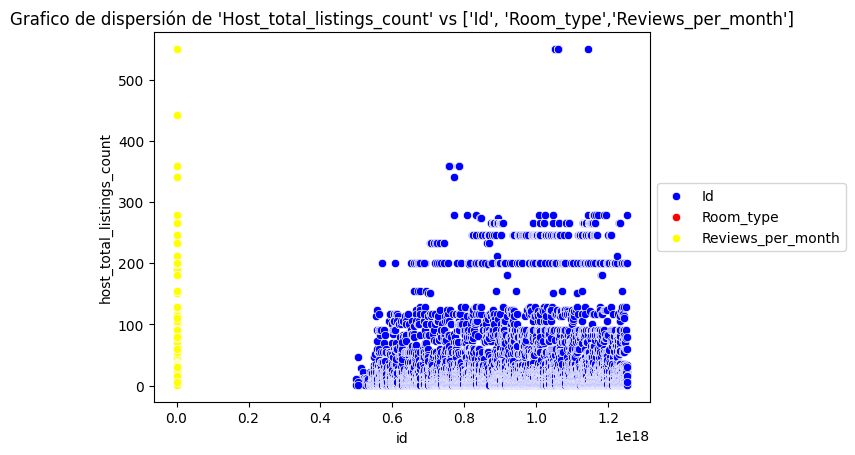

In [93]:
#Imprimimos el scater plot entre la variable dependiente e independientes 
#para observar el comportamiento en su dispersión

#(room_type vs [id, room_type, reviews_per_month])
sns.scatterplot(x='id', y='host_total_listings_count', color="blue", data=df)
sns.scatterplot(x='room_type', y='host_total_listings_count', color="red", data=df)
sns.scatterplot(x='reviews_per_month', y='host_total_listings_count', color="yellow", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión de 'Host_total_listings_count' vs ['Id', 'Room_type','Reviews_per_month']")

# Agregar la leyenda manualmente
plt.legend(labels=["Id", "Room_type", "Reviews_per_month"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [94]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['id', 'room_type', 'reviews_per_month']]
Var_Dep= df['host_total_listings_count']

In [95]:
model= LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [96]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

LinearRegression()

In [97]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['id', 'room_type', 'reviews_per_month'], dtype=object),
 'n_features_in_': 3,
 'coef_': array([1.42350092e-17, 0.00000000e+00, 0.00000000e+00]),
 'rank_': 1,
 'singular_': array([7.97114737e+19, 2.20713170e+02, 1.54282913e+02]),
 'intercept_': np.float64(14.95836174222121)}

In [98]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.0173563081632353

In [99]:
#Predecimos los valores mediante 3 variables
y_pred= model.predict(X=df[['id', 'room_type', 'reviews_per_month']])
y_pred

array([14.95836174, 14.95836174, 14.95836174, ..., 32.78323519,
       32.78370147, 32.78385535], shape=(26582,))

In [100]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(38, 'Predicciones_host_total_listings_count_multiple', y_pred)
df

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,review_scores_value,reviews_per_month,Predicciones_id_simple,Predicciones_id_multiple,Predicciones_host_acceptance_rate_simple,Predicciones_host_acceptance_rate_multiple,Predicciones_host_is_superhost_simple,Predicciones_host_is_superhost_multiple,Predicciones_host_total_listings_count_simple,Predicciones_host_total_listings_count_multiple
0,0,0,35797,1.00,1.00,1.0,1.0,19.383820,-99.200000,2.0,...,4.70,1.70,5.366552e+17,5.609180e+17,0.944546,0.941850,0.373554,0.375877,14.958362,14.958362
1,1,0,44616,1.00,0.93,12.0,13.0,19.411620,-99.177940,3.1,...,4.48,0.41,4.579289e+17,4.517855e+17,0.917681,0.951754,0.270558,0.164577,14.958362,14.958362
2,1,0,67703,0.71,0.57,3.0,4.0,19.411520,-99.168570,4.0,...,4.91,0.31,4.518261e+17,4.516995e+17,0.915599,0.950087,0.262574,0.167083,14.958362,14.958362
3,1,0,70644,1.00,1.00,3.0,4.0,19.356140,-99.163080,2.0,...,4.92,0.83,4.835608e+17,4.651347e+17,0.926428,0.958753,0.304092,0.410792,14.958362,14.958362
4,1,0,107078,1.00,1.00,5.0,7.0,19.432110,-99.193270,2.0,...,4.82,0.11,4.396205e+17,4.724216e+17,0.911434,0.946754,0.246606,0.321074,14.958362,14.958362
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26577,1,2,1252141718111439700,1.00,1.00,167.0,279.0,19.387329,-99.246731,4.0,...,4.70,1.70,5.366552e+17,7.796836e+17,0.944546,0.947139,0.373554,0.375877,32.782611,32.782611
26578,0,2,1252159821531694005,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,4.70,1.70,5.366552e+17,5.567261e+17,0.944546,0.915738,0.373554,0.375877,32.782868,32.782868
26579,0,2,1252185591721328995,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,4.70,1.70,5.366552e+17,5.549141e+17,0.944546,0.915738,0.373554,0.375877,32.783235,32.783235
26580,0,2,1252218347521498445,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,4.70,1.70,5.366552e+17,5.531022e+17,0.944546,0.915738,0.373554,0.375877,32.783701,32.783701


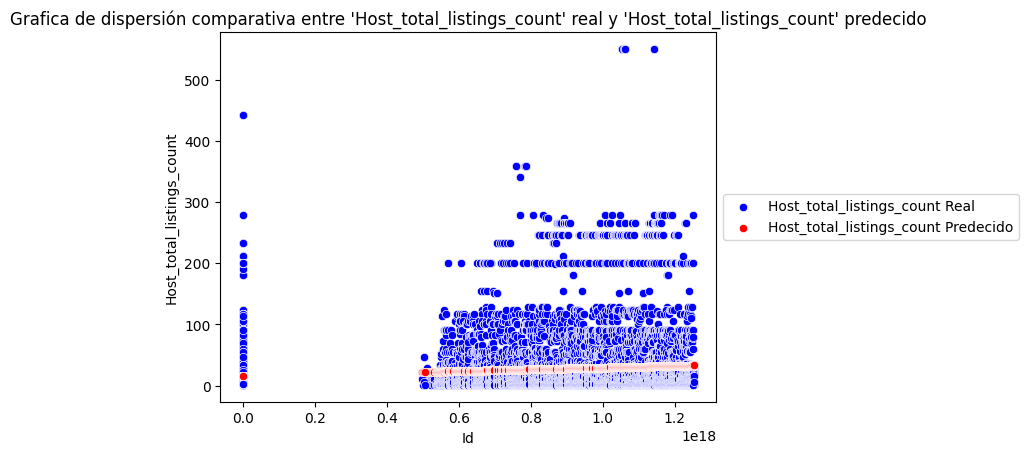

In [101]:
sns.scatterplot(x='id', y='host_total_listings_count', color="blue", data=df)
sns.scatterplot(x='id', y='Predicciones_host_total_listings_count_multiple', color="red", data=df)
#sns.lineplot(x='id', y='Predicciones_host_total_listings_count_multiple', color="red", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafica de dispersión comparativa entre 'Host_total_listings_count' real y 'Host_total_listings_count' predecido")
plt.xlabel("Id")
plt.ylabel("Host_total_listings_count")

# Agregar la leyenda manualmente
plt.legend(labels=["Host_total_listings_count Real", "Host_total_listings_count Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [102]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
resultados[("Lineal Multiple","Prediccion_host_total_listings_count","determinacion")] = coef_Deter
coef_Deter

0.0173563081632353

In [103]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
resultados[("Lineal Multiple","Prediccion_host_total_listings_count","correlacion")] = coef_Correl
coef_Correl

np.float64(0.13174334200723503)

# **Variable 5: room_type**

**Lineal Simple**

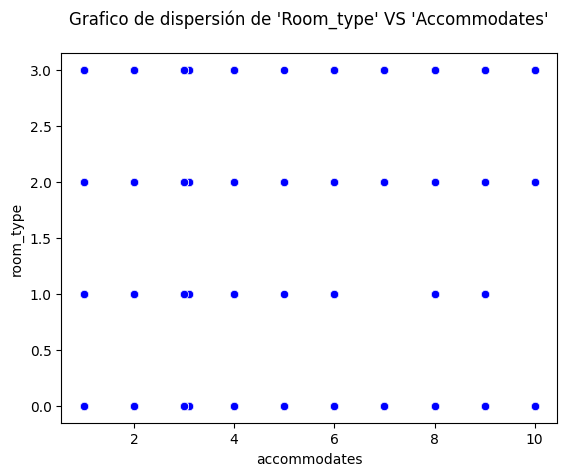

In [104]:
#Imprimimos el scater plot entre la variable dependiente e independiente 
#para observar el comportamiento en su dispersión

#(room_type vs accommodates)
sns.scatterplot(x='accommodates', y='room_type', color="blue", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión de 'Room_type' VS 'Accommodates'\n")

# Mostrar la gráfica
plt.show()

In [105]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['accommodates']]
Var_Dep= df['room_type']

In [106]:
model= LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [107]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

LinearRegression()

In [108]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['accommodates'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([-0.26405677]),
 'rank_': 1,
 'singular_': array([285.70648599]),
 'intercept_': np.float64(1.5270404906572415)}

In [109]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.2246879997408262

In [110]:
#Predecimos los valores mediante 3 variables
y_pred= model.predict(X=df[['accommodates']])
y_pred

array([0.99892694, 0.70846449, 0.47081339, ..., 0.99892694, 0.99892694,
       0.99892694], shape=(26582,))

In [111]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(39, 'Predicciones_room_type_simple', y_pred)
df

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,reviews_per_month,Predicciones_id_simple,Predicciones_id_multiple,Predicciones_host_acceptance_rate_simple,Predicciones_host_acceptance_rate_multiple,Predicciones_host_is_superhost_simple,Predicciones_host_is_superhost_multiple,Predicciones_host_total_listings_count_simple,Predicciones_host_total_listings_count_multiple,Predicciones_room_type_simple
0,0,0,35797,1.00,1.00,1.0,1.0,19.383820,-99.200000,2.0,...,1.70,5.366552e+17,5.609180e+17,0.944546,0.941850,0.373554,0.375877,14.958362,14.958362,0.998927
1,1,0,44616,1.00,0.93,12.0,13.0,19.411620,-99.177940,3.1,...,0.41,4.579289e+17,4.517855e+17,0.917681,0.951754,0.270558,0.164577,14.958362,14.958362,0.708464
2,1,0,67703,0.71,0.57,3.0,4.0,19.411520,-99.168570,4.0,...,0.31,4.518261e+17,4.516995e+17,0.915599,0.950087,0.262574,0.167083,14.958362,14.958362,0.470813
3,1,0,70644,1.00,1.00,3.0,4.0,19.356140,-99.163080,2.0,...,0.83,4.835608e+17,4.651347e+17,0.926428,0.958753,0.304092,0.410792,14.958362,14.958362,0.998927
4,1,0,107078,1.00,1.00,5.0,7.0,19.432110,-99.193270,2.0,...,0.11,4.396205e+17,4.724216e+17,0.911434,0.946754,0.246606,0.321074,14.958362,14.958362,0.998927
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26577,1,2,1252141718111439700,1.00,1.00,167.0,279.0,19.387329,-99.246731,4.0,...,1.70,5.366552e+17,7.796836e+17,0.944546,0.947139,0.373554,0.375877,32.782611,32.782611,0.470813
26578,0,2,1252159821531694005,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,1.70,5.366552e+17,5.567261e+17,0.944546,0.915738,0.373554,0.375877,32.782868,32.782868,0.998927
26579,0,2,1252185591721328995,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,1.70,5.366552e+17,5.549141e+17,0.944546,0.915738,0.373554,0.375877,32.783235,32.783235,0.998927
26580,0,2,1252218347521498445,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,1.70,5.366552e+17,5.531022e+17,0.944546,0.915738,0.373554,0.375877,32.783701,32.783701,0.998927


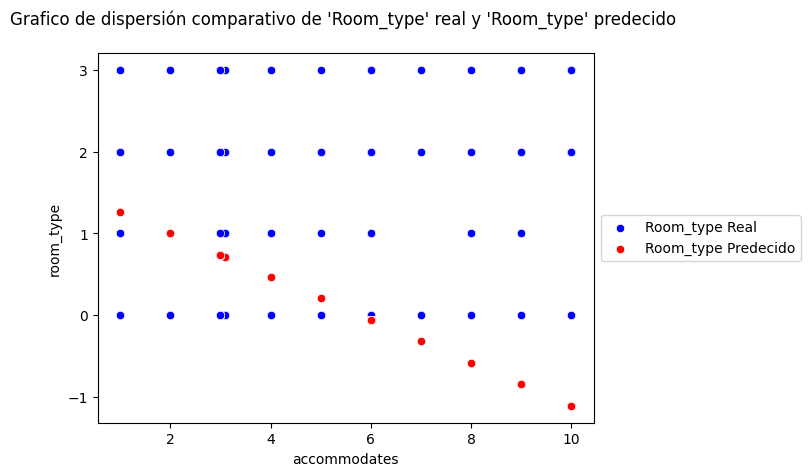

In [112]:
sns.scatterplot(x='accommodates', y='room_type', color="blue", data=df)
sns.scatterplot(x='accommodates', y='Predicciones_room_type_simple', color="red", data=df)
#sns.lineplot(x='accommodates', y='Predicciones_room_type_simple', color="red", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión comparativo de 'Room_type' real y 'Room_type' predecido \n")

# Agregar la leyenda manualmente
plt.legend(labels=["Room_type Real", "Room_type Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [113]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
resultados[("Lineal Simple","Prediccion_room_type","determinacion")] = coef_Deter
coef_Deter

0.2246879997408262

In [114]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
resultados[("Lineal Simple","Prediccion_room_type","correlacion")] = coef_Correl
coef_Correl

np.float64(0.4740126577854501)

**Lineal Múltiple**

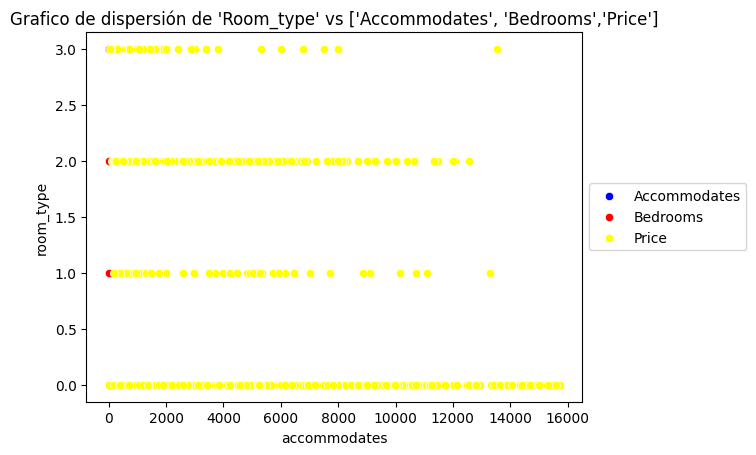

In [115]:
#Imprimimos el scater plot entre la variable dependiente e independientes 
#para observar el comportamiento en su dispersión

#(room_type vs [accommodates, bedrooms, price])
sns.scatterplot(x='accommodates', y='room_type', color="blue", data=df)
sns.scatterplot(x='bedrooms', y='room_type', color="red", data=df)
sns.scatterplot(x='price', y='room_type', color="yellow", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión de 'Room_type' vs ['Accommodates', 'Bedrooms','Price']")

# Agregar la leyenda manualmente
plt.legend(labels=["Accommodates", "Bedrooms", "Price"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [116]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['accommodates', 'bedrooms', 'price']]
Var_Dep= df['room_type']

In [117]:
model= LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [118]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

LinearRegression()

In [119]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['accommodates', 'bedrooms', 'price'], dtype=object),
 'n_features_in_': 3,
 'coef_': array([-2.43231074e-01,  3.88169564e-02, -1.22191327e-04]),
 'rank_': 3,
 'singular_': array([2.15040258e+05, 2.78540956e+02, 8.50002586e+01]),
 'intercept_': np.float64(1.5642116006683213)}

In [120]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.24774455148611618

In [121]:
#Predecimos los valores mediante 3 variables
y_pred= model.predict(X=df[['accommodates', 'bedrooms', 'price']])
y_pred

array([0.64429693, 0.85520663, 0.42099501, ..., 0.78664983, 0.79886896,
       0.95124154], shape=(26582,))

In [122]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(40, 'Predicciones_room_type_multiple', y_pred)
df

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,Predicciones_id_simple,Predicciones_id_multiple,Predicciones_host_acceptance_rate_simple,Predicciones_host_acceptance_rate_multiple,Predicciones_host_is_superhost_simple,Predicciones_host_is_superhost_multiple,Predicciones_host_total_listings_count_simple,Predicciones_host_total_listings_count_multiple,Predicciones_room_type_simple,Predicciones_room_type_multiple
0,0,0,35797,1.00,1.00,1.0,1.0,19.383820,-99.200000,2.0,...,5.366552e+17,5.609180e+17,0.944546,0.941850,0.373554,0.375877,14.958362,14.958362,0.998927,0.644297
1,1,0,44616,1.00,0.93,12.0,13.0,19.411620,-99.177940,3.1,...,4.579289e+17,4.517855e+17,0.917681,0.951754,0.270558,0.164577,14.958362,14.958362,0.708464,0.855207
2,1,0,67703,0.71,0.57,3.0,4.0,19.411520,-99.168570,4.0,...,4.518261e+17,4.516995e+17,0.915599,0.950087,0.262574,0.167083,14.958362,14.958362,0.470813,0.420995
3,1,0,70644,1.00,1.00,3.0,4.0,19.356140,-99.163080,2.0,...,4.835608e+17,4.651347e+17,0.926428,0.958753,0.304092,0.410792,14.958362,14.958362,0.998927,0.977268
4,1,0,107078,1.00,1.00,5.0,7.0,19.432110,-99.193270,2.0,...,4.396205e+17,4.724216e+17,0.911434,0.946754,0.246606,0.321074,14.958362,14.958362,0.998927,0.672645
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26577,1,2,1252141718111439700,1.00,1.00,167.0,279.0,19.387329,-99.246731,4.0,...,5.366552e+17,7.796836e+17,0.944546,0.947139,0.373554,0.375877,32.782611,32.782611,0.470813,0.609292
26578,0,2,1252159821531694005,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,5.366552e+17,5.567261e+17,0.944546,0.915738,0.373554,0.375877,32.782868,32.782868,0.998927,0.774431
26579,0,2,1252185591721328995,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,5.366552e+17,5.549141e+17,0.944546,0.915738,0.373554,0.375877,32.783235,32.783235,0.998927,0.786650
26580,0,2,1252218347521498445,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,5.366552e+17,5.531022e+17,0.944546,0.915738,0.373554,0.375877,32.783701,32.783701,0.998927,0.798869


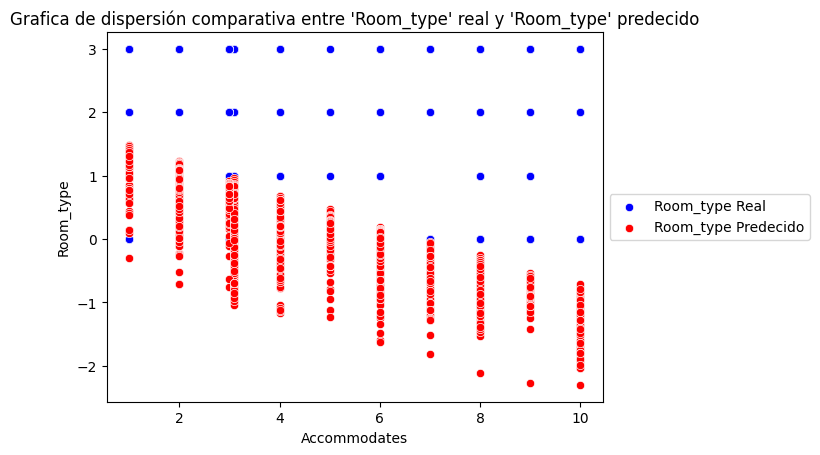

In [123]:
sns.scatterplot(x='accommodates', y='room_type', color="blue", data=df)
sns.scatterplot(x='accommodates', y='Predicciones_room_type_multiple', color="red", data=df)
#sns.lineplot(x='accommodates', y='Predicciones_room_type_multiple', color="red", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafica de dispersión comparativa entre 'Room_type' real y 'Room_type' predecido")
plt.xlabel("Accommodates")
plt.ylabel("Room_type")

# Agregar la leyenda manualmente
plt.legend(labels=["Room_type Real", "Room_type Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [124]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
resultados[("Lineal Multiple","Prediccion_room_type","determinacion")] = coef_Deter
coef_Deter

0.24774455148611618

In [125]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
resultados[("Lineal Multiple","Prediccion_room_type","correlacion")] = coef_Correl
coef_Correl

np.float64(0.4977394413607547)

# **Variable 6: accommodates**

**Lineal Simple**

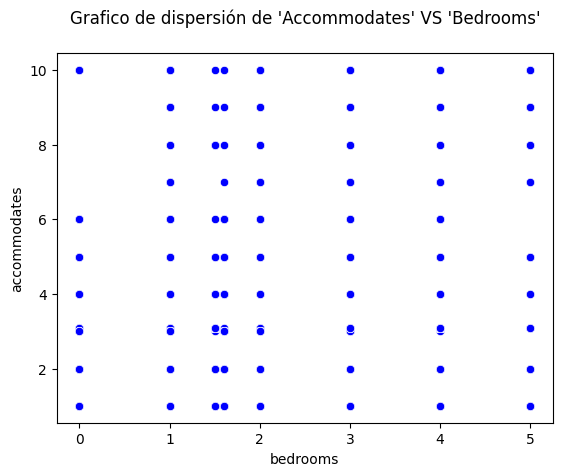

In [126]:
#Imprimimos el scater plot entre la variable dependiente e independiente 
#para observar el comportamiento en su dispersión

#(accommodates vs bedrooms)
sns.scatterplot(x='bedrooms', y='accommodates', color="blue", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión de 'Accommodates' VS 'Bedrooms'\n")

# Mostrar la gráfica
plt.show()

In [127]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['bedrooms']]
Var_Dep= df['accommodates']

In [128]:
model= LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [129]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

LinearRegression()

In [130]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['bedrooms'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([1.58183888]),
 'rank_': 1,
 'singular_': array([124.53966253]),
 'intercept_': np.float64(0.7635931242344447)}

In [131]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.475444317323356

In [132]:
#Predecimos los valores mediante 3 variables
y_pred= model.predict(X=df[['bedrooms']])
y_pred

array([2.345432  , 8.67278752, 3.92727088, ..., 2.345432  , 2.345432  ,
       2.345432  ], shape=(26582,))

In [133]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(41, 'Predicciones_accommodates_simple', y_pred)
df

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,Predicciones_id_multiple,Predicciones_host_acceptance_rate_simple,Predicciones_host_acceptance_rate_multiple,Predicciones_host_is_superhost_simple,Predicciones_host_is_superhost_multiple,Predicciones_host_total_listings_count_simple,Predicciones_host_total_listings_count_multiple,Predicciones_room_type_simple,Predicciones_room_type_multiple,Predicciones_accommodates_simple
0,0,0,35797,1.00,1.00,1.0,1.0,19.383820,-99.200000,2.0,...,5.609180e+17,0.944546,0.941850,0.373554,0.375877,14.958362,14.958362,0.998927,0.644297,2.345432
1,1,0,44616,1.00,0.93,12.0,13.0,19.411620,-99.177940,3.1,...,4.517855e+17,0.917681,0.951754,0.270558,0.164577,14.958362,14.958362,0.708464,0.855207,8.672788
2,1,0,67703,0.71,0.57,3.0,4.0,19.411520,-99.168570,4.0,...,4.516995e+17,0.915599,0.950087,0.262574,0.167083,14.958362,14.958362,0.470813,0.420995,3.927271
3,1,0,70644,1.00,1.00,3.0,4.0,19.356140,-99.163080,2.0,...,4.651347e+17,0.926428,0.958753,0.304092,0.410792,14.958362,14.958362,0.998927,0.977268,2.345432
4,1,0,107078,1.00,1.00,5.0,7.0,19.432110,-99.193270,2.0,...,4.724216e+17,0.911434,0.946754,0.246606,0.321074,14.958362,14.958362,0.998927,0.672645,2.345432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26577,1,2,1252141718111439700,1.00,1.00,167.0,279.0,19.387329,-99.246731,4.0,...,7.796836e+17,0.944546,0.947139,0.373554,0.375877,32.782611,32.782611,0.470813,0.609292,3.927271
26578,0,2,1252159821531694005,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,5.567261e+17,0.944546,0.915738,0.373554,0.375877,32.782868,32.782868,0.998927,0.774431,2.345432
26579,0,2,1252185591721328995,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,5.549141e+17,0.944546,0.915738,0.373554,0.375877,32.783235,32.783235,0.998927,0.786650,2.345432
26580,0,2,1252218347521498445,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,5.531022e+17,0.944546,0.915738,0.373554,0.375877,32.783701,32.783701,0.998927,0.798869,2.345432


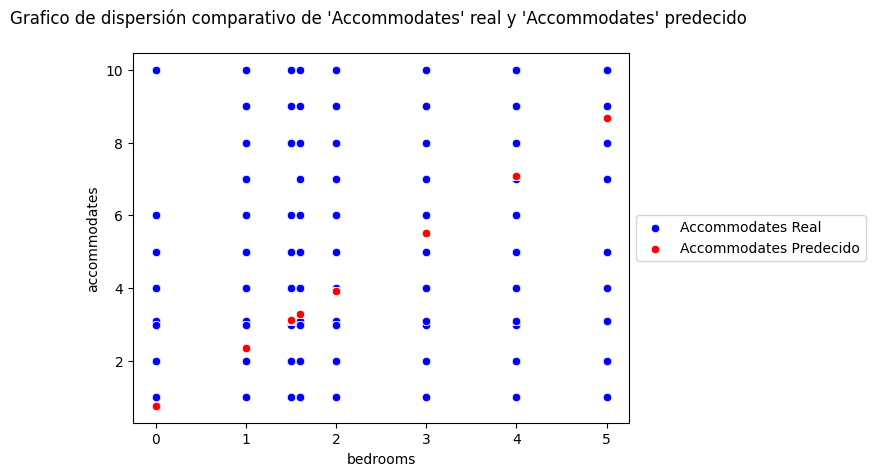

In [134]:
sns.scatterplot(x='bedrooms', y='accommodates', color="blue", data=df)
sns.scatterplot(x='bedrooms', y='Predicciones_accommodates_simple', color="red", data=df)
#sns.lineplot(x='bedrooms', y='Predicciones_accommodates_simple', color="red", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión comparativo de 'Accommodates' real y 'Accommodates' predecido \n")

# Agregar la leyenda manualmente
plt.legend(labels=["Accommodates Real", "Accommodates Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [135]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
resultados[("Lineal Simple","Prediccion_accommodates","determinacion")] = coef_Deter
coef_Deter

0.475444317323356

In [136]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
resultados[("Lineal Simple","Prediccion_accommodates","correlacion")] = coef_Correl
coef_Correl

np.float64(0.6895247039253605)

**Lineal Múltiple**

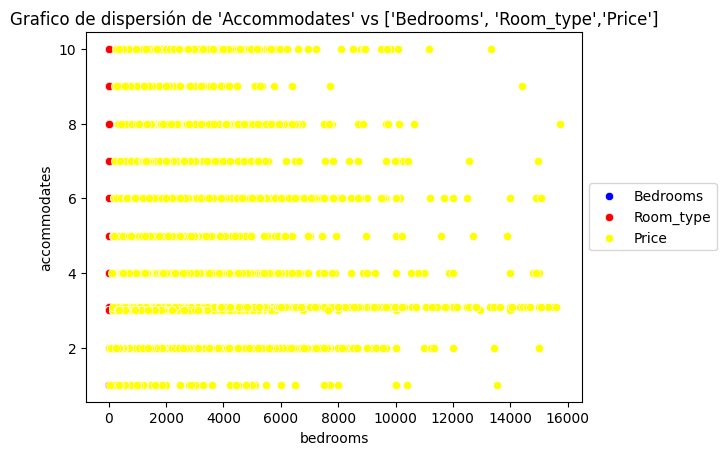

In [137]:
#Imprimimos el scater plot entre la variable dependiente e independientes 
#para observar el comportamiento en su dispersión

#(bedrooms vs [bedrooms, room_type, price])
sns.scatterplot(x='bedrooms', y='accommodates', color="blue", data=df)
sns.scatterplot(x='room_type', y='accommodates', color="red", data=df)
sns.scatterplot(x='price', y='accommodates', color="yellow", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión de 'Accommodates' vs ['Bedrooms', 'Room_type','Price']")

# Agregar la leyenda manualmente
plt.legend(labels=["Bedrooms", "Room_type", "Price"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [138]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['bedrooms', 'room_type', 'price']]
Var_Dep= df['accommodates']

In [139]:
model= LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [140]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

LinearRegression()

In [141]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['bedrooms', 'room_type', 'price'], dtype=object),
 'n_features_in_': 3,
 'coef_': array([ 1.33301833e+00, -4.73495817e-01,  7.47295587e-05]),
 'rank_': 3,
 'singular_': array([2.15040240e+05, 1.56798117e+02, 1.08223097e+02]),
 'intercept_': np.float64(1.3693570301881741)}

In [142]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.5455593407041779

In [143]:
#Predecimos los valores mediante 3 variables
y_pred= model.predict(X=df[['bedrooms', 'room_type', 'price']])
y_pred

array([2.9912051 , 8.12561872, 4.18701996, ..., 1.95715353, 1.94968057,
       2.80348445], shape=(26582,))

In [144]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(42, 'Predicciones_accommodates_multiple', y_pred)
df

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,Predicciones_host_acceptance_rate_simple,Predicciones_host_acceptance_rate_multiple,Predicciones_host_is_superhost_simple,Predicciones_host_is_superhost_multiple,Predicciones_host_total_listings_count_simple,Predicciones_host_total_listings_count_multiple,Predicciones_room_type_simple,Predicciones_room_type_multiple,Predicciones_accommodates_simple,Predicciones_accommodates_multiple
0,0,0,35797,1.00,1.00,1.0,1.0,19.383820,-99.200000,2.0,...,0.944546,0.941850,0.373554,0.375877,14.958362,14.958362,0.998927,0.644297,2.345432,2.991205
1,1,0,44616,1.00,0.93,12.0,13.0,19.411620,-99.177940,3.1,...,0.917681,0.951754,0.270558,0.164577,14.958362,14.958362,0.708464,0.855207,8.672788,8.125619
2,1,0,67703,0.71,0.57,3.0,4.0,19.411520,-99.168570,4.0,...,0.915599,0.950087,0.262574,0.167083,14.958362,14.958362,0.470813,0.420995,3.927271,4.187020
3,1,0,70644,1.00,1.00,3.0,4.0,19.356140,-99.163080,2.0,...,0.926428,0.958753,0.304092,0.410792,14.958362,14.958362,0.998927,0.977268,2.345432,2.787567
4,1,0,107078,1.00,1.00,5.0,7.0,19.432110,-99.193270,2.0,...,0.911434,0.946754,0.246606,0.321074,14.958362,14.958362,0.998927,0.672645,2.345432,2.973868
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26577,1,2,1252141718111439700,1.00,1.00,167.0,279.0,19.387329,-99.246731,4.0,...,0.944546,0.947139,0.373554,0.375877,32.782611,32.782611,0.470813,0.609292,3.927271,3.124870
26578,0,2,1252159821531694005,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,0.944546,0.915738,0.373554,0.375877,32.782868,32.782868,0.998927,0.774431,2.345432,1.964626
26579,0,2,1252185591721328995,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,0.944546,0.915738,0.373554,0.375877,32.783235,32.783235,0.998927,0.786650,2.345432,1.957154
26580,0,2,1252218347521498445,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,0.944546,0.915738,0.373554,0.375877,32.783701,32.783701,0.998927,0.798869,2.345432,1.949681


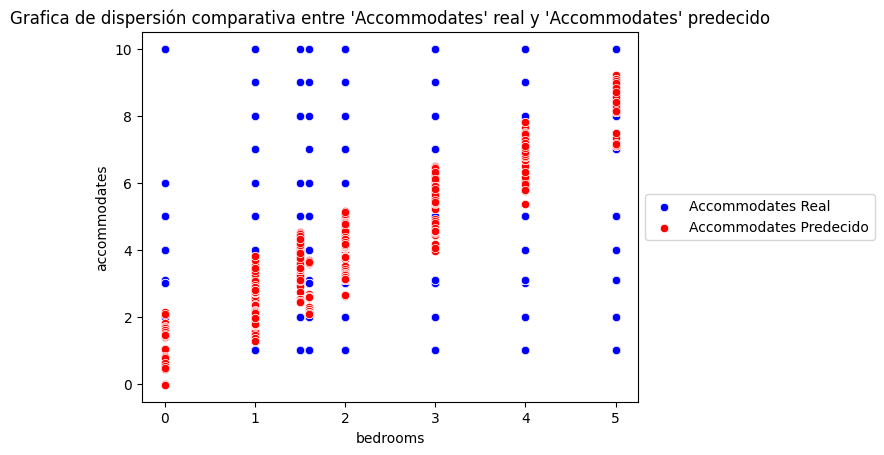

In [145]:
sns.scatterplot(x='bedrooms', y='accommodates', color="blue", data=df)
sns.scatterplot(x='bedrooms', y='Predicciones_accommodates_multiple', color="red", data=df)
#sns.lineplot(x='bedrooms', y='Predicciones_accommodates_multiple', color="red", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafica de dispersión comparativa entre 'Accommodates' real y 'Accommodates' predecido")

# Agregar la leyenda manualmente
plt.legend(labels=["Accommodates Real", "Accommodates Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [146]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
resultados[("Lineal Multiple","Prediccion_accommodates","determinacion")] = coef_Deter
coef_Deter

0.5455593407041779

In [147]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
resultados[("Lineal Multiple","Prediccion_accommodates","correlacion")] = coef_Correl
coef_Correl

np.float64(0.7386198891880572)

# **Variable 7: bedrooms**

**Lineal Simple**

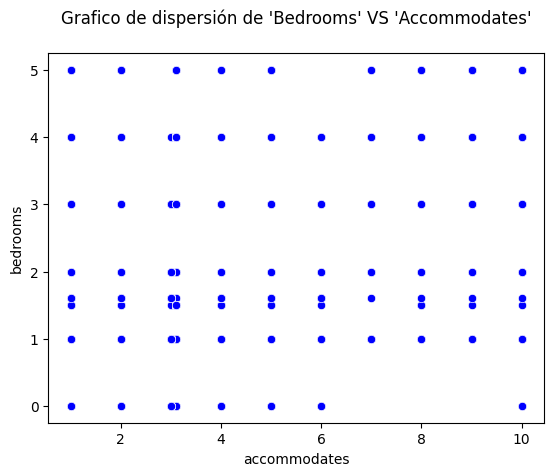

In [148]:
#Imprimimos el scater plot entre la variable dependiente e independiente 
#para observar el comportamiento en su dispersión

#(bedrooms vs accommodates)
sns.scatterplot(x='accommodates', y='bedrooms', color="blue", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión de 'Bedrooms' VS 'Accommodates'\n")

# Mostrar la gráfica
plt.show()

In [149]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['accommodates']]
Var_Dep= df['bedrooms']

In [150]:
model= LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [151]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

LinearRegression()

In [152]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['accommodates'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.30056431]),
 'rank_': 1,
 'singular_': array([285.70648599]),
 'intercept_': np.float64(0.5508639352850211)}

In [153]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.4754443173233561

In [154]:
#Predecimos los valores mediante 3 variables
y_pred= model.predict(X=df[['accommodates']])
y_pred

array([1.15199256, 1.48261331, 1.75312119, ..., 1.15199256, 1.15199256,
       1.15199256], shape=(26582,))

In [155]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(43, 'Predicciones_bedrooms_simple', y_pred)
df

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,Predicciones_host_acceptance_rate_multiple,Predicciones_host_is_superhost_simple,Predicciones_host_is_superhost_multiple,Predicciones_host_total_listings_count_simple,Predicciones_host_total_listings_count_multiple,Predicciones_room_type_simple,Predicciones_room_type_multiple,Predicciones_accommodates_simple,Predicciones_accommodates_multiple,Predicciones_bedrooms_simple
0,0,0,35797,1.00,1.00,1.0,1.0,19.383820,-99.200000,2.0,...,0.941850,0.373554,0.375877,14.958362,14.958362,0.998927,0.644297,2.345432,2.991205,1.151993
1,1,0,44616,1.00,0.93,12.0,13.0,19.411620,-99.177940,3.1,...,0.951754,0.270558,0.164577,14.958362,14.958362,0.708464,0.855207,8.672788,8.125619,1.482613
2,1,0,67703,0.71,0.57,3.0,4.0,19.411520,-99.168570,4.0,...,0.950087,0.262574,0.167083,14.958362,14.958362,0.470813,0.420995,3.927271,4.187020,1.753121
3,1,0,70644,1.00,1.00,3.0,4.0,19.356140,-99.163080,2.0,...,0.958753,0.304092,0.410792,14.958362,14.958362,0.998927,0.977268,2.345432,2.787567,1.151993
4,1,0,107078,1.00,1.00,5.0,7.0,19.432110,-99.193270,2.0,...,0.946754,0.246606,0.321074,14.958362,14.958362,0.998927,0.672645,2.345432,2.973868,1.151993
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26577,1,2,1252141718111439700,1.00,1.00,167.0,279.0,19.387329,-99.246731,4.0,...,0.947139,0.373554,0.375877,32.782611,32.782611,0.470813,0.609292,3.927271,3.124870,1.753121
26578,0,2,1252159821531694005,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,0.915738,0.373554,0.375877,32.782868,32.782868,0.998927,0.774431,2.345432,1.964626,1.151993
26579,0,2,1252185591721328995,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,0.915738,0.373554,0.375877,32.783235,32.783235,0.998927,0.786650,2.345432,1.957154,1.151993
26580,0,2,1252218347521498445,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,0.915738,0.373554,0.375877,32.783701,32.783701,0.998927,0.798869,2.345432,1.949681,1.151993


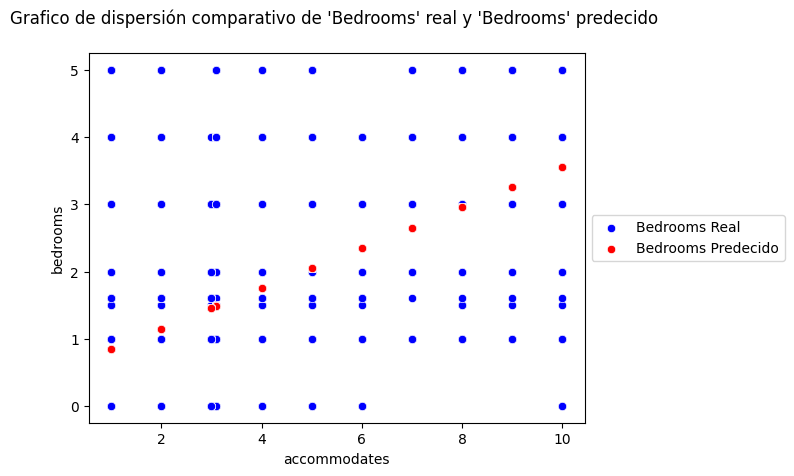

In [156]:
sns.scatterplot(x='accommodates', y='bedrooms', color="blue", data=df)
sns.scatterplot(x='accommodates', y='Predicciones_bedrooms_simple', color="red", data=df)
#sns.lineplot(x='accommodates', y='Predicciones_bedrooms_simple', color="red", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión comparativo de 'Bedrooms' real y 'Bedrooms' predecido \n")

# Agregar la leyenda manualmente
plt.legend(labels=["Bedrooms Real", "Bedrooms Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [157]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
resultados[("Lineal Simple","Prediccion_bedrooms","determinacion")] = coef_Deter
coef_Deter

0.4754443173233561

In [158]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
resultados[("Lineal Simple","Prediccion_bedrooms","correlacion")] = coef_Correl
coef_Correl

np.float64(0.6895247039253606)

**Lineal Múltiple**

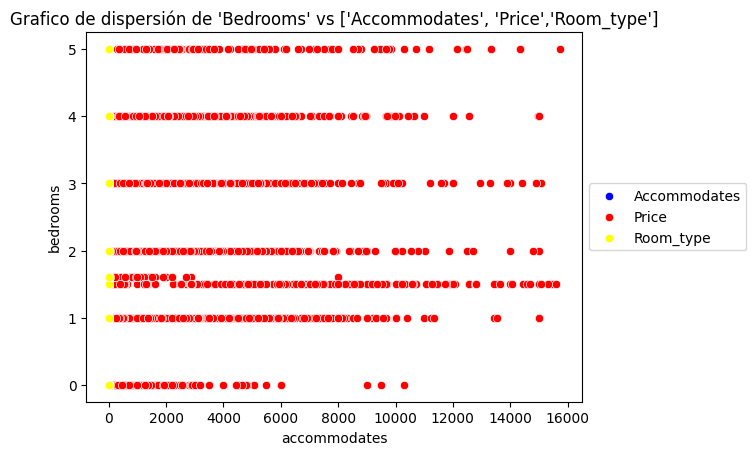

In [159]:
#Imprimimos el scater plot entre la variable dependiente e independientes 
#para observar el comportamiento en su dispersión

#(bedrooms vs [accommodates, price, room_type])
sns.scatterplot(x='accommodates', y='bedrooms', color="blue", data=df)
sns.scatterplot(x='price', y='bedrooms', color="red", data=df)
sns.scatterplot(x='room_type', y='bedrooms', color="yellow", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión de 'Bedrooms' vs ['Accommodates', 'Price','Room_type']")

# Agregar la leyenda manualmente
plt.legend(labels=["Accommodates", "Price", "Room_type"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [160]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['accommodates', 'price', 'room_type']]
Var_Dep= df['bedrooms']

In [161]:
model= LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [162]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

LinearRegression()

In [163]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['accommodates', 'price', 'room_type'], dtype=object),
 'n_features_in_': 3,
 'coef_': array([2.81793874e-01, 8.64500091e-05, 1.59740117e-02]),
 'rank_': 3,
 'singular_': array([2.15040258e+05, 2.76728098e+02, 1.33370504e+02]),
 'intercept_': np.float64(0.48504420794868564)}

In [164]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.49441120591916343

In [165]:
#Predecimos los valores mediante 3 variables
y_pred= model.predict(X=df[['accommodates', 'price', 'room_type']])
y_pred

array([1.38276124, 1.46407423, 1.78762677, ..., 1.313995  , 1.30535   ,
       1.16559882], shape=(26582,))

In [166]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(44, 'Predicciones_bedrooms_multiple', y_pred)
df

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,Predicciones_host_is_superhost_simple,Predicciones_host_is_superhost_multiple,Predicciones_host_total_listings_count_simple,Predicciones_host_total_listings_count_multiple,Predicciones_room_type_simple,Predicciones_room_type_multiple,Predicciones_accommodates_simple,Predicciones_accommodates_multiple,Predicciones_bedrooms_simple,Predicciones_bedrooms_multiple
0,0,0,35797,1.00,1.00,1.0,1.0,19.383820,-99.200000,2.0,...,0.373554,0.375877,14.958362,14.958362,0.998927,0.644297,2.345432,2.991205,1.151993,1.382761
1,1,0,44616,1.00,0.93,12.0,13.0,19.411620,-99.177940,3.1,...,0.270558,0.164577,14.958362,14.958362,0.708464,0.855207,8.672788,8.125619,1.482613,1.464074
2,1,0,67703,0.71,0.57,3.0,4.0,19.411520,-99.168570,4.0,...,0.262574,0.167083,14.958362,14.958362,0.470813,0.420995,3.927271,4.187020,1.753121,1.787627
3,1,0,70644,1.00,1.00,3.0,4.0,19.356140,-99.163080,2.0,...,0.304092,0.410792,14.958362,14.958362,0.998927,0.977268,2.345432,2.787567,1.151993,1.147185
4,1,0,107078,1.00,1.00,5.0,7.0,19.432110,-99.193270,2.0,...,0.246606,0.321074,14.958362,14.958362,0.998927,0.672645,2.345432,2.973868,1.151993,1.362705
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26577,1,2,1252141718111439700,1.00,1.00,167.0,279.0,19.387329,-99.246731,4.0,...,0.373554,0.375877,32.782611,32.782611,0.470813,0.609292,3.927271,3.124870,1.753121,1.686355
26578,0,2,1252159821531694005,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,0.373554,0.375877,32.782868,32.782868,0.998927,0.774431,2.345432,1.964626,1.151993,1.322640
26579,0,2,1252185591721328995,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,0.373554,0.375877,32.783235,32.783235,0.998927,0.786650,2.345432,1.957154,1.151993,1.313995
26580,0,2,1252218347521498445,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,0.373554,0.375877,32.783701,32.783701,0.998927,0.798869,2.345432,1.949681,1.151993,1.305350


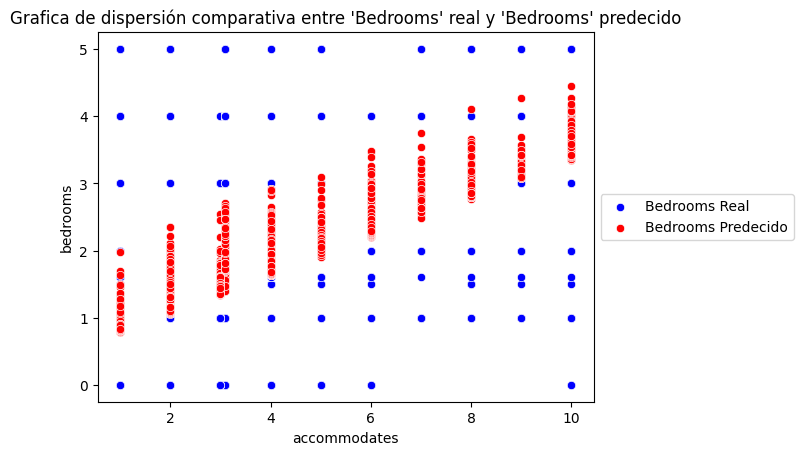

In [167]:
sns.scatterplot(x='accommodates', y='bedrooms', color="blue", data=df)
sns.scatterplot(x='accommodates', y='Predicciones_bedrooms_multiple', color="red", data=df)
#sns.lineplot(x='accommodates', y='Predicciones_bedrooms_multiple', color="red", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafica de dispersión comparativa entre 'Bedrooms' real y 'Bedrooms' predecido")

# Agregar la leyenda manualmente
plt.legend(labels=["Bedrooms Real", "Bedrooms Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [168]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
resultados[("Lineal Multiple","Prediccion_bedrooms","determinacion")] = coef_Deter
coef_Deter

0.49441120591916343

In [169]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
resultados[("Lineal Multiple","Prediccion_bedrooms","correlacion")] = coef_Correl
coef_Correl

np.float64(0.7031438017355791)

# **Variable 8: price**

**Lineal Simple**

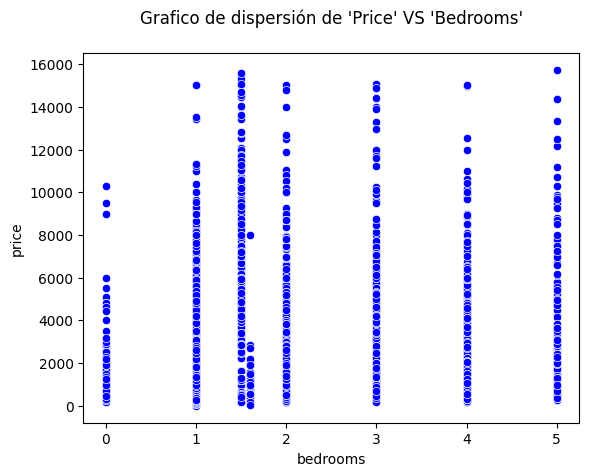

In [170]:
#Imprimimos el scater plot entre la variable dependiente e independiente 
#para observar el comportamiento en su dispersión

#(price vs bedrooms)
sns.scatterplot(x='bedrooms', y='price', color="blue", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión de 'Price' VS 'Bedrooms'\n")

# Mostrar la gráfica
plt.show()

In [171]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['bedrooms']]
Var_Dep= df['price']

In [172]:
model= LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [173]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

LinearRegression()

In [174]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['bedrooms'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([641.25301087]),
 'rank_': 1,
 'singular_': array([124.53966253]),
 'intercept_': np.float64(354.0444636795811)}

In [175]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.1379223903754524

In [176]:
#Predecimos los valores mediante 3 variables
y_pred= model.predict(X=df[['bedrooms']])
y_pred

array([ 995.29747454, 3560.30951801, 1636.55048541, ...,  995.29747454,
        995.29747454,  995.29747454], shape=(26582,))

In [177]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(45, 'Predicciones_price_simple', y_pred)
df

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,Predicciones_host_is_superhost_multiple,Predicciones_host_total_listings_count_simple,Predicciones_host_total_listings_count_multiple,Predicciones_room_type_simple,Predicciones_room_type_multiple,Predicciones_accommodates_simple,Predicciones_accommodates_multiple,Predicciones_bedrooms_simple,Predicciones_bedrooms_multiple,Predicciones_price_simple
0,0,0,35797,1.00,1.00,1.0,1.0,19.383820,-99.200000,2.0,...,0.375877,14.958362,14.958362,0.998927,0.644297,2.345432,2.991205,1.151993,1.382761,995.297475
1,1,0,44616,1.00,0.93,12.0,13.0,19.411620,-99.177940,3.1,...,0.164577,14.958362,14.958362,0.708464,0.855207,8.672788,8.125619,1.482613,1.464074,3560.309518
2,1,0,67703,0.71,0.57,3.0,4.0,19.411520,-99.168570,4.0,...,0.167083,14.958362,14.958362,0.470813,0.420995,3.927271,4.187020,1.753121,1.787627,1636.550485
3,1,0,70644,1.00,1.00,3.0,4.0,19.356140,-99.163080,2.0,...,0.410792,14.958362,14.958362,0.998927,0.977268,2.345432,2.787567,1.151993,1.147185,995.297475
4,1,0,107078,1.00,1.00,5.0,7.0,19.432110,-99.193270,2.0,...,0.321074,14.958362,14.958362,0.998927,0.672645,2.345432,2.973868,1.151993,1.362705,995.297475
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26577,1,2,1252141718111439700,1.00,1.00,167.0,279.0,19.387329,-99.246731,4.0,...,0.375877,32.782611,32.782611,0.470813,0.609292,3.927271,3.124870,1.753121,1.686355,1636.550485
26578,0,2,1252159821531694005,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,0.375877,32.782868,32.782868,0.998927,0.774431,2.345432,1.964626,1.151993,1.322640,995.297475
26579,0,2,1252185591721328995,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,0.375877,32.783235,32.783235,0.998927,0.786650,2.345432,1.957154,1.151993,1.313995,995.297475
26580,0,2,1252218347521498445,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,0.375877,32.783701,32.783701,0.998927,0.798869,2.345432,1.949681,1.151993,1.305350,995.297475


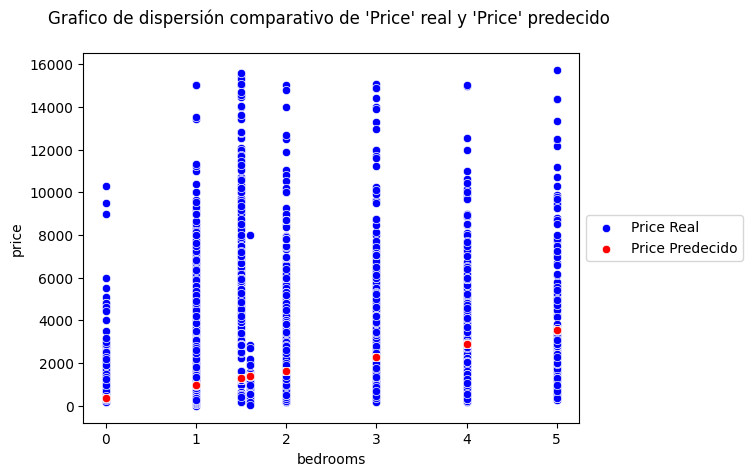

In [178]:
sns.scatterplot(x='bedrooms', y='price', color="blue", data=df)
sns.scatterplot(x='bedrooms', y='Predicciones_price_simple', color="red", data=df)
#sns.lineplot(x='bedrooms', y='Predicciones_price_simple', color="red", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión comparativo de 'Price' real y 'Price' predecido \n")

# Agregar la leyenda manualmente
plt.legend(labels=["Price Real", "Price Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [179]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
resultados[("Lineal Simple","Prediccion_price","determinacion")] = coef_Deter
coef_Deter

0.1379223903754524

In [180]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
resultados[("Lineal Simple","Prediccion_price","correlacion")] = coef_Correl
coef_Correl

np.float64(0.3713790386861547)

**Lineal Múltiple**

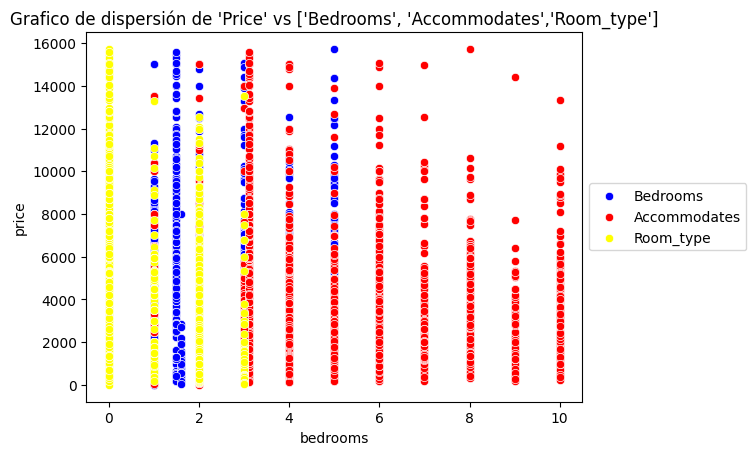

In [181]:
#Imprimimos el scater plot entre la variable dependiente e independientes 
#para observar el comportamiento en su dispersión

#(price vs [bedrooms, accommodates, room_type])
sns.scatterplot(x='bedrooms', y='price', color="blue", data=df)
sns.scatterplot(x='accommodates', y='price', color="red", data=df)
sns.scatterplot(x='room_type', y='price', color="yellow", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión de 'Price' vs ['Bedrooms', 'Accommodates','Room_type']")

# Agregar la leyenda manualmente
plt.legend(labels=["Bedrooms", "Accommodates", "Room_type"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [182]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['bedrooms', 'accommodates', 'room_type']]
Var_Dep= df['price']

In [183]:
model= LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [184]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

LinearRegression()

In [185]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['bedrooms', 'accommodates', 'room_type'], dtype=object),
 'n_features_in_': 3,
 'coef_': array([ 417.5231054 ,   76.29627168, -242.85573826]),
 'rank_': 3,
 'singular_': array([311.18665644, 135.10826478,  85.89585458]),
 'intercept_': np.float64(620.0512034345006)}

In [186]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.18099066640066608

In [187]:
#Predecimos los valores mediante 3 variables
y_pred= model.predict(X=df[['bedrooms', 'accommodates', 'room_type']])
y_pred

array([1190.1668522 , 2944.18517267, 1760.28250097, ...,  704.45537567,
        704.45537567, 1190.1668522 ], shape=(26582,))

In [188]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(46, 'Predicciones_price_multiple', y_pred)
df

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,Predicciones_host_total_listings_count_simple,Predicciones_host_total_listings_count_multiple,Predicciones_room_type_simple,Predicciones_room_type_multiple,Predicciones_accommodates_simple,Predicciones_accommodates_multiple,Predicciones_bedrooms_simple,Predicciones_bedrooms_multiple,Predicciones_price_simple,Predicciones_price_multiple
0,0,0,35797,1.00,1.00,1.0,1.0,19.383820,-99.200000,2.0,...,14.958362,14.958362,0.998927,0.644297,2.345432,2.991205,1.151993,1.382761,995.297475,1190.166852
1,1,0,44616,1.00,0.93,12.0,13.0,19.411620,-99.177940,3.1,...,14.958362,14.958362,0.708464,0.855207,8.672788,8.125619,1.482613,1.464074,3560.309518,2944.185173
2,1,0,67703,0.71,0.57,3.0,4.0,19.411520,-99.168570,4.0,...,14.958362,14.958362,0.470813,0.420995,3.927271,4.187020,1.753121,1.787627,1636.550485,1760.282501
3,1,0,70644,1.00,1.00,3.0,4.0,19.356140,-99.163080,2.0,...,14.958362,14.958362,0.998927,0.977268,2.345432,2.787567,1.151993,1.147185,995.297475,1190.166852
4,1,0,107078,1.00,1.00,5.0,7.0,19.432110,-99.193270,2.0,...,14.958362,14.958362,0.998927,0.672645,2.345432,2.973868,1.151993,1.362705,995.297475,1190.166852
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26577,1,2,1252141718111439700,1.00,1.00,167.0,279.0,19.387329,-99.246731,4.0,...,32.782611,32.782611,0.470813,0.609292,3.927271,3.124870,1.753121,1.686355,1636.550485,1274.571024
26578,0,2,1252159821531694005,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,32.782868,32.782868,0.998927,0.774431,2.345432,1.964626,1.151993,1.322640,995.297475,704.455376
26579,0,2,1252185591721328995,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,32.783235,32.783235,0.998927,0.786650,2.345432,1.957154,1.151993,1.313995,995.297475,704.455376
26580,0,2,1252218347521498445,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,32.783701,32.783701,0.998927,0.798869,2.345432,1.949681,1.151993,1.305350,995.297475,704.455376


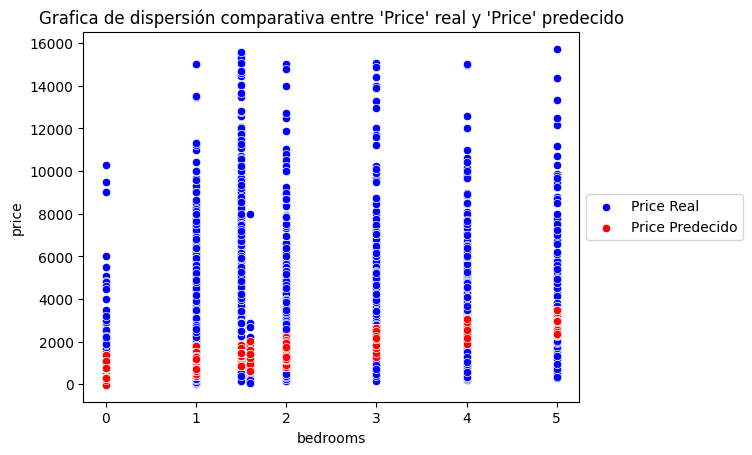

In [189]:
sns.scatterplot(x='bedrooms', y='price', color="blue", data=df)
sns.scatterplot(x='bedrooms', y='Predicciones_price_multiple', color="red", data=df)
#sns.lineplot(x='bedrooms', y='Predicciones_price_multiple', color="red", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafica de dispersión comparativa entre 'Price' real y 'Price' predecido")

# Agregar la leyenda manualmente
plt.legend(labels=["Price Real", "Price Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [190]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
resultados[("Lineal Multiple","Prediccion_price","determinacion")] = coef_Deter
coef_Deter

0.18099066640066608

In [191]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
resultados[("Lineal Multiple","Prediccion_price","correlacion")] = coef_Correl
coef_Correl

np.float64(0.4254299782580749)

# **Variable 9: review_scores_value**

**Lineal Simple**

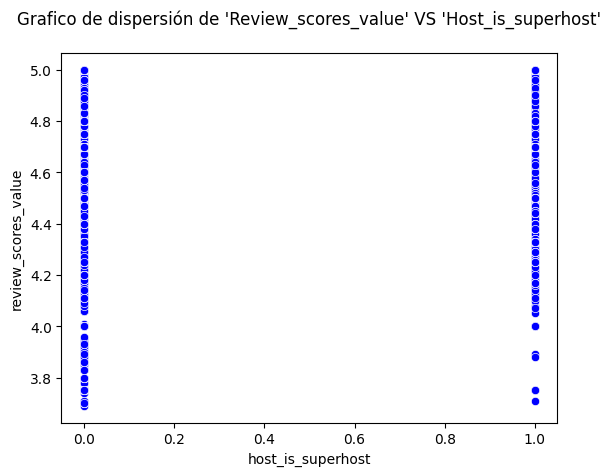

In [192]:
#Imprimimos el scater plot entre la variable dependiente e independiente 
#para observar el comportamiento en su dispersión

#(review_scores_value vs host_is_superhost)
sns.scatterplot(x='host_is_superhost', y='review_scores_value', color="blue", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión de 'Review_scores_value' VS 'Host_is_superhost'\n")

# Mostrar la gráfica
plt.show()

In [193]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['host_is_superhost']]
Var_Dep= df['review_scores_value']

In [194]:
model= LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [195]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

LinearRegression()

In [196]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['host_is_superhost'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.08655838]),
 'rank_': 1,
 'singular_': array([78.53441437]),
 'intercept_': np.float64(4.724853159299908)}

In [197]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.03877854195986741

In [198]:
#Predecimos los valores mediante 3 variables
y_pred= model.predict(X=df[['host_is_superhost']])
y_pred

array([4.72485316, 4.81141153, 4.81141153, ..., 4.72485316, 4.72485316,
       4.81141153], shape=(26582,))

In [199]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(47, 'Predicciones_review_scores_value_simple', y_pred)
df

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,Predicciones_host_total_listings_count_multiple,Predicciones_room_type_simple,Predicciones_room_type_multiple,Predicciones_accommodates_simple,Predicciones_accommodates_multiple,Predicciones_bedrooms_simple,Predicciones_bedrooms_multiple,Predicciones_price_simple,Predicciones_price_multiple,Predicciones_review_scores_value_simple
0,0,0,35797,1.00,1.00,1.0,1.0,19.383820,-99.200000,2.0,...,14.958362,0.998927,0.644297,2.345432,2.991205,1.151993,1.382761,995.297475,1190.166852,4.724853
1,1,0,44616,1.00,0.93,12.0,13.0,19.411620,-99.177940,3.1,...,14.958362,0.708464,0.855207,8.672788,8.125619,1.482613,1.464074,3560.309518,2944.185173,4.811412
2,1,0,67703,0.71,0.57,3.0,4.0,19.411520,-99.168570,4.0,...,14.958362,0.470813,0.420995,3.927271,4.187020,1.753121,1.787627,1636.550485,1760.282501,4.811412
3,1,0,70644,1.00,1.00,3.0,4.0,19.356140,-99.163080,2.0,...,14.958362,0.998927,0.977268,2.345432,2.787567,1.151993,1.147185,995.297475,1190.166852,4.811412
4,1,0,107078,1.00,1.00,5.0,7.0,19.432110,-99.193270,2.0,...,14.958362,0.998927,0.672645,2.345432,2.973868,1.151993,1.362705,995.297475,1190.166852,4.811412
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26577,1,2,1252141718111439700,1.00,1.00,167.0,279.0,19.387329,-99.246731,4.0,...,32.782611,0.470813,0.609292,3.927271,3.124870,1.753121,1.686355,1636.550485,1274.571024,4.811412
26578,0,2,1252159821531694005,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,32.782868,0.998927,0.774431,2.345432,1.964626,1.151993,1.322640,995.297475,704.455376,4.724853
26579,0,2,1252185591721328995,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,32.783235,0.998927,0.786650,2.345432,1.957154,1.151993,1.313995,995.297475,704.455376,4.724853
26580,0,2,1252218347521498445,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,32.783701,0.998927,0.798869,2.345432,1.949681,1.151993,1.305350,995.297475,704.455376,4.724853


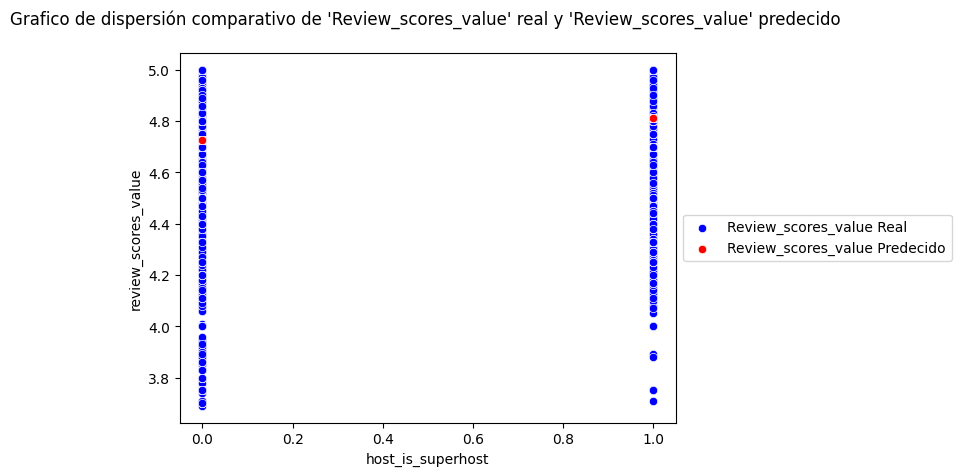

In [200]:
sns.scatterplot(x='host_is_superhost', y='review_scores_value', color="blue", data=df)
sns.scatterplot(x='host_is_superhost', y='Predicciones_review_scores_value_simple', color="red", data=df)
#sns.lineplot(x='host_is_superhost', y='Predicciones_review_scores_value_simple', color="red", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión comparativo de 'Review_scores_value' real y 'Review_scores_value' predecido \n")

# Agregar la leyenda manualmente
plt.legend(labels=["Review_scores_value Real", "Review_scores_value Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [201]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
resultados[("Lineal Simple","Prediccion_review_scores_value","determinacion")] = coef_Deter
coef_Deter

0.03877854195986741

In [202]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
resultados[("Lineal Simple","Prediccion_review_scores_value","correlacion")] = coef_Correl
coef_Correl

np.float64(0.19692268015611458)

**Lineal Múltiple**

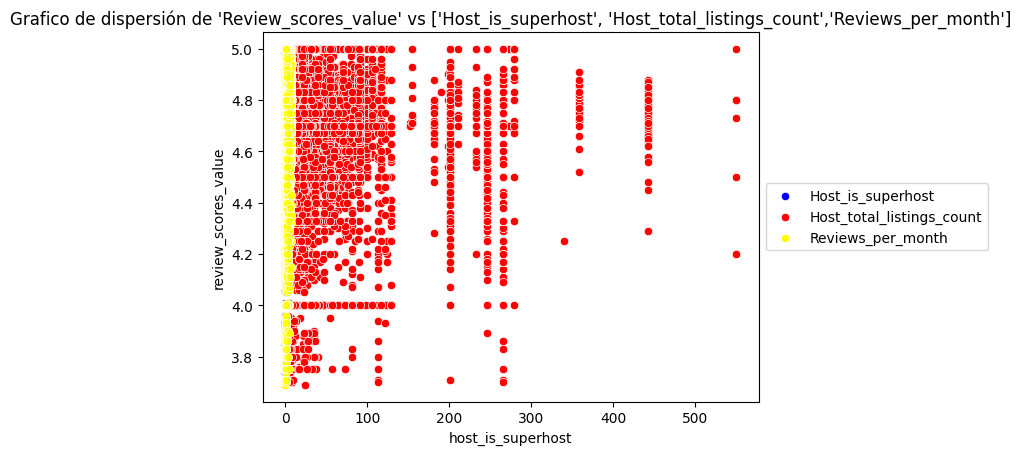

In [203]:
#Imprimimos el scater plot entre la variable dependiente e independientes 
#para observar el comportamiento en su dispersión

#(reviews_per_month vs [host_is_superhost, host_total_listings_count, reviews_per_month])
sns.scatterplot(x='host_is_superhost', y='review_scores_value', color="blue", data=df)
sns.scatterplot(x='host_total_listings_count', y='review_scores_value', color="red", data=df)
sns.scatterplot(x='reviews_per_month', y='review_scores_value', color="yellow", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión de 'Review_scores_value' vs ['Host_is_superhost', 'Host_total_listings_count','Reviews_per_month']")

# Agregar la leyenda manualmente
plt.legend(labels=["Host_is_superhost", "Host_total_listings_count", "Reviews_per_month"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [204]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['host_is_superhost', 'host_total_listings_count', 'reviews_per_month']]
Var_Dep= df['review_scores_value']

In [205]:
model= LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [206]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

LinearRegression()

In [207]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['host_is_superhost', 'host_total_listings_count',
        'reviews_per_month'], dtype=object),
 'n_features_in_': 3,
 'coef_': array([ 0.08485469, -0.00047457,  0.00415334]),
 'rank_': 3,
 'singular_': array([8612.94708012,  219.92407015,   76.25345697]),
 'intercept_': np.float64(4.729497590159092)}

In [208]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.052770407445375644

In [209]:
#Predecimos los valores mediante 3 variables
y_pred= model.predict(X=df[['host_is_superhost', 'host_total_listings_count', 'reviews_per_month']])
y_pred

array([4.7360837 , 4.80988574, 4.81374154, ..., 4.72896514, 4.72896514,
       4.81856554], shape=(26582,))

In [210]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(48, 'Predicciones_review_scores_value_multiple', y_pred)
df

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,Predicciones_room_type_simple,Predicciones_room_type_multiple,Predicciones_accommodates_simple,Predicciones_accommodates_multiple,Predicciones_bedrooms_simple,Predicciones_bedrooms_multiple,Predicciones_price_simple,Predicciones_price_multiple,Predicciones_review_scores_value_simple,Predicciones_review_scores_value_multiple
0,0,0,35797,1.00,1.00,1.0,1.0,19.383820,-99.200000,2.0,...,0.998927,0.644297,2.345432,2.991205,1.151993,1.382761,995.297475,1190.166852,4.724853,4.736084
1,1,0,44616,1.00,0.93,12.0,13.0,19.411620,-99.177940,3.1,...,0.708464,0.855207,8.672788,8.125619,1.482613,1.464074,3560.309518,2944.185173,4.811412,4.809886
2,1,0,67703,0.71,0.57,3.0,4.0,19.411520,-99.168570,4.0,...,0.470813,0.420995,3.927271,4.187020,1.753121,1.787627,1636.550485,1760.282501,4.811412,4.813742
3,1,0,70644,1.00,1.00,3.0,4.0,19.356140,-99.163080,2.0,...,0.998927,0.977268,2.345432,2.787567,1.151993,1.147185,995.297475,1190.166852,4.811412,4.815901
4,1,0,107078,1.00,1.00,5.0,7.0,19.432110,-99.193270,2.0,...,0.998927,0.672645,2.345432,2.973868,1.151993,1.362705,995.297475,1190.166852,4.811412,4.811487
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26577,1,2,1252141718111439700,1.00,1.00,167.0,279.0,19.387329,-99.246731,4.0,...,0.470813,0.609292,3.927271,3.124870,1.753121,1.686355,1636.550485,1274.571024,4.811412,4.689008
26578,0,2,1252159821531694005,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,0.998927,0.774431,2.345432,1.964626,1.151993,1.322640,995.297475,704.455376,4.724853,4.728965
26579,0,2,1252185591721328995,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,0.998927,0.786650,2.345432,1.957154,1.151993,1.313995,995.297475,704.455376,4.724853,4.728965
26580,0,2,1252218347521498445,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,0.998927,0.798869,2.345432,1.949681,1.151993,1.305350,995.297475,704.455376,4.724853,4.728965


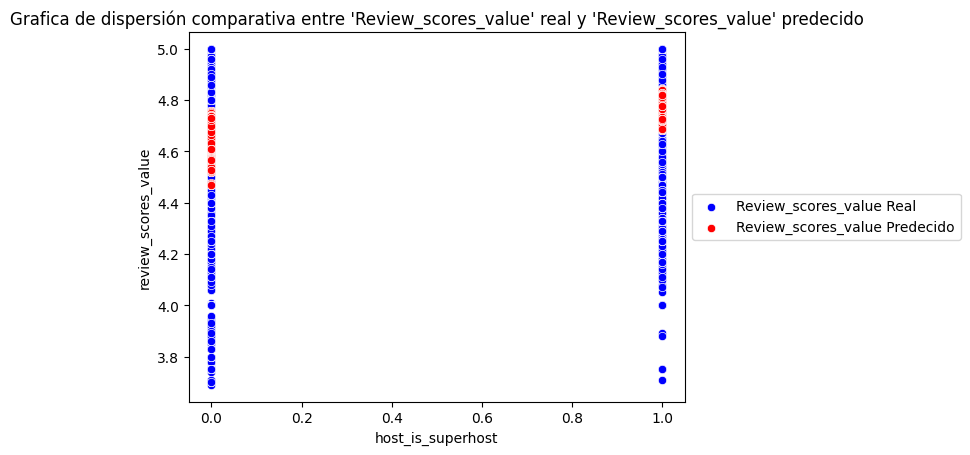

In [211]:
sns.scatterplot(x='host_is_superhost', y='review_scores_value', color="blue", data=df)
sns.scatterplot(x='host_is_superhost', y='Predicciones_review_scores_value_multiple', color="red", data=df)
#sns.lineplot(x='host_is_superhost', y='Predicciones_review_scores_value_multiple', color="red", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafica de dispersión comparativa entre 'Review_scores_value' real y 'Review_scores_value' predecido")

# Agregar la leyenda manualmente
plt.legend(labels=["Review_scores_value Real", "Review_scores_value Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [212]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
resultados[("Lineal Multiple","Prediccion_review_scores_value","determinacion")] = coef_Deter
coef_Deter

0.052770407445375644

In [213]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
resultados[("Lineal Multiple","Prediccion_review_scores_value","correlacion")] = coef_Correl
coef_Correl

np.float64(0.22971810430476663)

# **Variable 10: reviews_per_month**

**Lineal Simple**

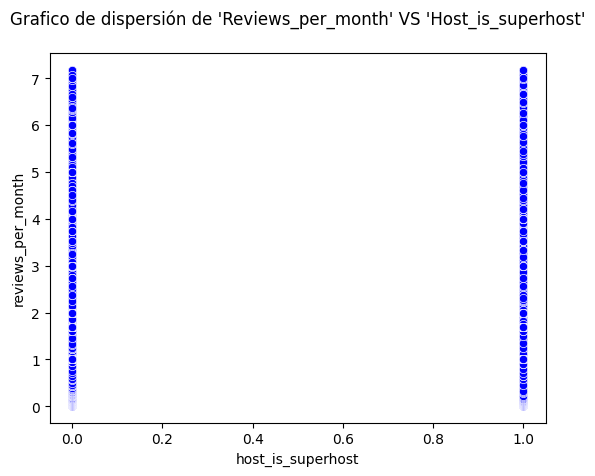

In [214]:
#Imprimimos el scater plot entre la variable dependiente e independiente 
#para observar el comportamiento en su dispersión

#(reviews_per_month vs host_is_superhost)
sns.scatterplot(x='host_is_superhost', y='reviews_per_month', color="blue", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión de 'Reviews_per_month' VS 'Host_is_superhost'\n")

# Mostrar la gráfica
plt.show()

In [215]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['host_is_superhost']]
Var_Dep= df['reviews_per_month']

In [216]:
model= LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [217]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

LinearRegression()

In [218]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['host_is_superhost'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.62978788]),
 'rank_': 1,
 'singular_': array([78.53441437]),
 'intercept_': np.float64(1.3739810145357236)}

In [219]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.05028339687977057

In [220]:
#Predecimos los valores mediante 3 variables
y_pred= model.predict(X=df[['host_is_superhost']])
y_pred

array([1.37398101, 2.00376889, 2.00376889, ..., 1.37398101, 1.37398101,
       2.00376889], shape=(26582,))

In [221]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(49, 'Predicciones_reviews_per_month_simple', y_pred)
df

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,Predicciones_room_type_multiple,Predicciones_accommodates_simple,Predicciones_accommodates_multiple,Predicciones_bedrooms_simple,Predicciones_bedrooms_multiple,Predicciones_price_simple,Predicciones_price_multiple,Predicciones_review_scores_value_simple,Predicciones_review_scores_value_multiple,Predicciones_reviews_per_month_simple
0,0,0,35797,1.00,1.00,1.0,1.0,19.383820,-99.200000,2.0,...,0.644297,2.345432,2.991205,1.151993,1.382761,995.297475,1190.166852,4.724853,4.736084,1.373981
1,1,0,44616,1.00,0.93,12.0,13.0,19.411620,-99.177940,3.1,...,0.855207,8.672788,8.125619,1.482613,1.464074,3560.309518,2944.185173,4.811412,4.809886,2.003769
2,1,0,67703,0.71,0.57,3.0,4.0,19.411520,-99.168570,4.0,...,0.420995,3.927271,4.187020,1.753121,1.787627,1636.550485,1760.282501,4.811412,4.813742,2.003769
3,1,0,70644,1.00,1.00,3.0,4.0,19.356140,-99.163080,2.0,...,0.977268,2.345432,2.787567,1.151993,1.147185,995.297475,1190.166852,4.811412,4.815901,2.003769
4,1,0,107078,1.00,1.00,5.0,7.0,19.432110,-99.193270,2.0,...,0.672645,2.345432,2.973868,1.151993,1.362705,995.297475,1190.166852,4.811412,4.811487,2.003769
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26577,1,2,1252141718111439700,1.00,1.00,167.0,279.0,19.387329,-99.246731,4.0,...,0.609292,3.927271,3.124870,1.753121,1.686355,1636.550485,1274.571024,4.811412,4.689008,2.003769
26578,0,2,1252159821531694005,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,0.774431,2.345432,1.964626,1.151993,1.322640,995.297475,704.455376,4.724853,4.728965,1.373981
26579,0,2,1252185591721328995,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,0.786650,2.345432,1.957154,1.151993,1.313995,995.297475,704.455376,4.724853,4.728965,1.373981
26580,0,2,1252218347521498445,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,0.798869,2.345432,1.949681,1.151993,1.305350,995.297475,704.455376,4.724853,4.728965,1.373981


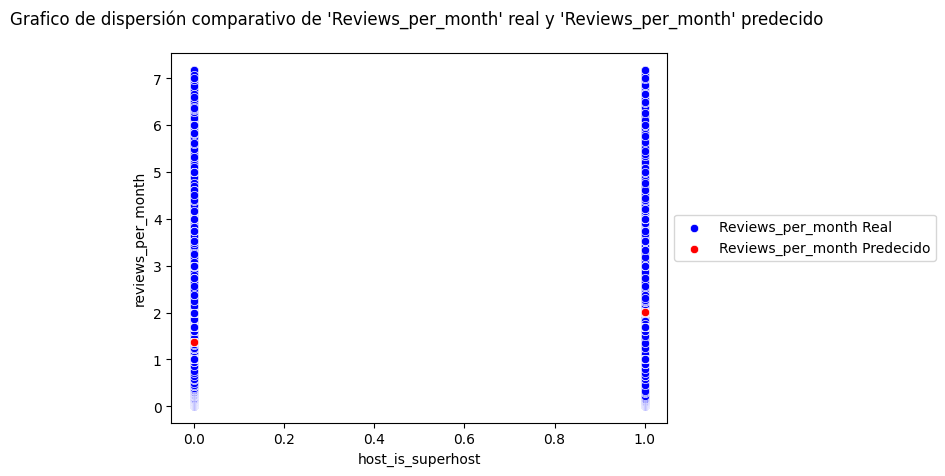

In [222]:
sns.scatterplot(x='host_is_superhost', y='reviews_per_month', color="blue", data=df)
sns.scatterplot(x='host_is_superhost', y='Predicciones_reviews_per_month_simple', color="red", data=df)
#sns.lineplot(x='host_is_superhost', y='Predicciones_reviews_per_month_simple', color="red", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión comparativo de 'Reviews_per_month' real y 'Reviews_per_month' predecido \n")

# Agregar la leyenda manualmente
plt.legend(labels=["Reviews_per_month Real", "Reviews_per_month Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [223]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
resultados[("Lineal Simple","Prediccion_reviews_per_month","determinacion")] = coef_Deter
coef_Deter

0.05028339687977057

In [224]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
resultados[("Lineal Simple","Prediccion_reviews_per_month","correlacion")] = coef_Correl
coef_Correl

np.float64(0.22423959703801327)

**Lineal Múltiple**

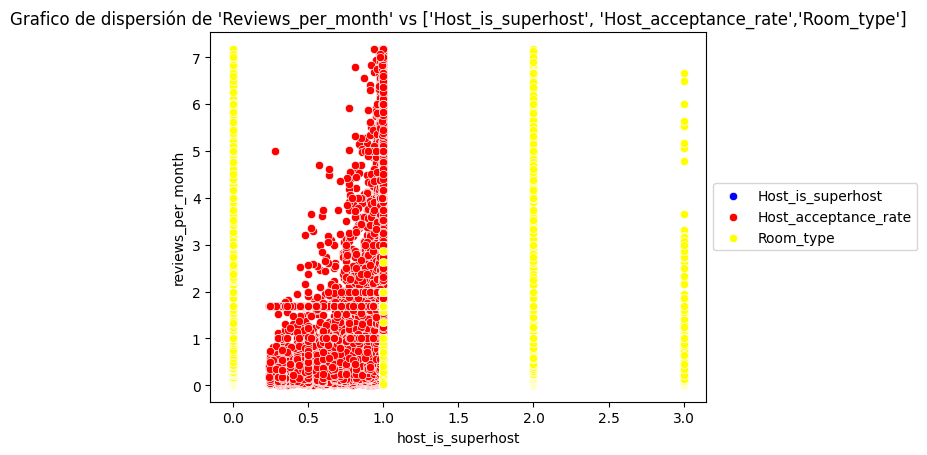

In [225]:
#Imprimimos el scater plot entre la variable dependiente e independientes 
#para observar el comportamiento en su dispersión

#(reviews_per_month vs [host_is_superhost, host_acceptance_rate, room_type])
sns.scatterplot(x='host_is_superhost', y='reviews_per_month', color="blue", data=df)
sns.scatterplot(x='host_acceptance_rate', y='reviews_per_month', color="red", data=df)
sns.scatterplot(x='room_type', y='reviews_per_month', color="yellow", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafico de dispersión de 'Reviews_per_month' vs ['Host_is_superhost', 'Host_acceptance_rate','Room_type']")

# Agregar la leyenda manualmente
plt.legend(labels=["Host_is_superhost", "Host_acceptance_rate", "Room_type"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [226]:
#Declaramos las variables dependientes e independientes para la regresión lineal
Vars_Indep= df[['host_is_superhost', 'host_acceptance_rate', 'room_type']]
Var_Dep= df['reviews_per_month']

In [227]:
model= LinearRegression()
type(model)

sklearn.linear_model._base.LinearRegression

In [228]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

LinearRegression()

In [229]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['host_is_superhost', 'host_acceptance_rate', 'room_type'],
       dtype=object),
 'n_features_in_': 3,
 'coef_': array([ 0.49291634,  1.75783807, -0.16924195]),
 'rank_': 3,
 'singular_': array([159.85789262,  77.23275804,  20.68775498]),
 'intercept_': np.float64(-0.11364754418446932)}

In [230]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.09739588050643122

In [231]:
#Predecimos los valores mediante 3 variables
y_pred= model.predict(X=df[['host_is_superhost', 'host_acceptance_rate', 'room_type']])
y_pred

array([1.64419053, 2.0140582 , 1.3812365 , ..., 1.30570663, 1.30570663,
       2.13710687], shape=(26582,))

In [232]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(50, 'Predicciones_reviews_per_month_multiple', y_pred)
df

,host_is_superhost,room_type,id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,...,Predicciones_accommodates_simple,Predicciones_accommodates_multiple,Predicciones_bedrooms_simple,Predicciones_bedrooms_multiple,Predicciones_price_simple,Predicciones_price_multiple,Predicciones_review_scores_value_simple,Predicciones_review_scores_value_multiple,Predicciones_reviews_per_month_simple,Predicciones_reviews_per_month_multiple
0,0,0,35797,1.00,1.00,1.0,1.0,19.383820,-99.200000,2.0,...,2.345432,2.991205,1.151993,1.382761,995.297475,1190.166852,4.724853,4.736084,1.373981,1.644191
1,1,0,44616,1.00,0.93,12.0,13.0,19.411620,-99.177940,3.1,...,8.672788,8.125619,1.482613,1.464074,3560.309518,2944.185173,4.811412,4.809886,2.003769,2.014058
2,1,0,67703,0.71,0.57,3.0,4.0,19.411520,-99.168570,4.0,...,3.927271,4.187020,1.753121,1.787627,1636.550485,1760.282501,4.811412,4.813742,2.003769,1.381236
3,1,0,70644,1.00,1.00,3.0,4.0,19.356140,-99.163080,2.0,...,2.345432,2.787567,1.151993,1.147185,995.297475,1190.166852,4.811412,4.815901,2.003769,2.137107
4,1,0,107078,1.00,1.00,5.0,7.0,19.432110,-99.193270,2.0,...,2.345432,2.973868,1.151993,1.362705,995.297475,1190.166852,4.811412,4.811487,2.003769,2.137107
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26577,1,2,1252141718111439700,1.00,1.00,167.0,279.0,19.387329,-99.246731,4.0,...,3.927271,3.124870,1.753121,1.686355,1636.550485,1274.571024,4.811412,4.689008,2.003769,1.798623
26578,0,2,1252159821531694005,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,2.345432,1.964626,1.151993,1.322640,995.297475,704.455376,4.724853,4.728965,1.373981,1.305707
26579,0,2,1252185591721328995,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,2.345432,1.957154,1.151993,1.313995,995.297475,704.455376,4.724853,4.728965,1.373981,1.305707
26580,0,2,1252218347521498445,1.00,1.00,16.0,16.0,19.432687,-99.197736,2.0,...,2.345432,1.949681,1.151993,1.305350,995.297475,704.455376,4.724853,4.728965,1.373981,1.305707


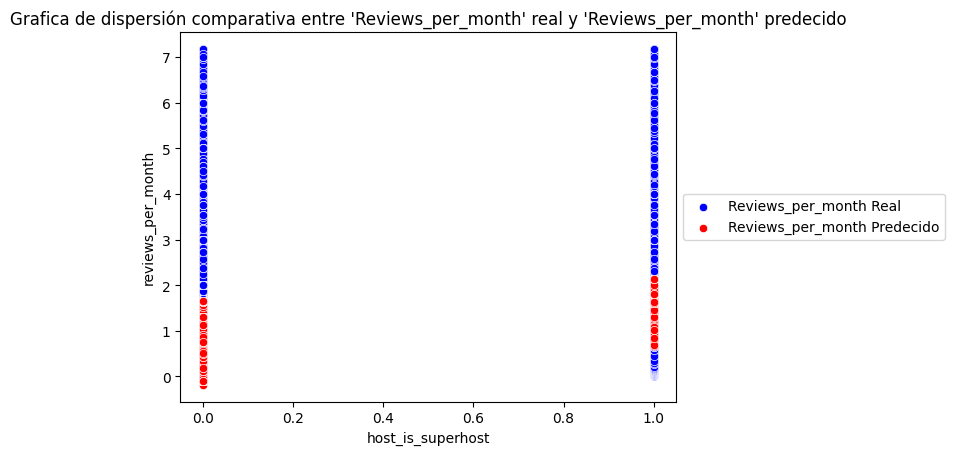

In [233]:
sns.scatterplot(x='host_is_superhost', y='reviews_per_month', color="blue", data=df)
sns.scatterplot(x='host_is_superhost', y='Predicciones_reviews_per_month_multiple', color="red", data=df)
#sns.lineplot(x='host_is_superhost', y='Predicciones_reviews_per_month_multiple', color="red", data=df)

# Configurar el título, etiquetas y leyenda
plt.title("Grafica de dispersión comparativa entre 'Reviews_per_month' real y 'Reviews_per_month' predecido")

# Agregar la leyenda manualmente
plt.legend(labels=["Reviews_per_month Real", "Reviews_per_month Predecido"], loc="center left", bbox_to_anchor=(1, 0.5))

# Mostrar la gráfica
plt.show()

In [234]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
resultados[("Lineal Multiple","Prediccion_reviews_per_month","determinacion")] = coef_Deter
coef_Deter

0.09739588050643122

In [235]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
resultados[("Lineal Multiple","Prediccion_reviews_per_month","correlacion")] = coef_Correl
coef_Correl

np.float64(0.3120831307623519)

# Tabla de coeficientes de determinación y correlación

In [236]:
filas = []
for (modelo, prediccion, tipo), valor in resultados.items():
    filas.append({"Modelo": modelo, "Predicción": prediccion, "Tipo": tipo, "Valor": valor})

# Crear DataFrame
df_res = pd.DataFrame(filas)

# Mostrar la tabla con formato pivotado
df_pivot = df_res.pivot(index=["Modelo", "Predicción"], columns="Tipo", values="Valor")
df_pivot

Tipo                                                  correlacion  \
Modelo          Predicción                                          
Lineal Multiple Prediccion_accommodates                  0.738620   
                Prediccion_bedrooms                      0.703144   
                Prediccion_host_acceptance_rate          0.268411   
                Prediccion_host_is_superhost             0.316423   
                Prediccion_host_total_listings_count     0.131743   
                Prediccion_id                            0.209032   
                Prediccion_price                         0.425430   
                Prediccion_review_scores_value           0.229718   
                Prediccion_reviews_per_month             0.312083   
                Prediccion_room_type                     0.497739   
Lineal Simple   Prediccion_accommodates                  0.689525   
                Prediccion_bedrooms                      0.689525   
                Prediccion_host_acceptance_rate          0.216869   
                Prediccion_host_is_superhost             0.224240   
                Prediccion_host_total_listings_count     0.131743   
                Prediccion_id                            0.168870   
                Prediccion_price                         0.371379   
                Prediccion_review_scores_value           0.196923   
                Prediccion_reviews_per_month             0.224240   
                Prediccion_room_type                     0.474013   

Tipo                                                  determinacion  
Modelo          Predicción                                           
Lineal Multiple Prediccion_accommodates                    0.545559  
                Prediccion_bedrooms                        0.494411  
                Prediccion_host_acceptance_rate            0.072045  
                Prediccion_host_is_superhost               0.100123  
                Prediccion_host_total_listings_count       0.017356  
                Prediccion_id                              0.043694  
                Prediccion_price                           0.180991  
                Prediccion_review_scores_value             0.052770  
                Prediccion_reviews_per_month               0.097396  
                Prediccion_room_type                       0.247745  
Lineal Simple   Prediccion_accommodates                    0.475444  
                Prediccion_bedrooms                        0.475444  
                Prediccion_host_acceptance_rate            0.047032  
                Prediccion_host_is_superhost               0.050283  
                Prediccion_host_total_listings_count       0.017356  
                Prediccion_id                              0.028517  
                Prediccion_price                           0.137922  
                Prediccion_review_scores_value             0.038779  
                Prediccion_reviews_per_month               0.050283  
                Prediccion_room_type                       0.224688

In [237]:
def mostrarTabla():
    print(f"Tabla para la Predicción: {comparacion}")
    df_res_pivot

# Filtrar las comparaciones únicas (asumimos que tienes 7 comparaciones distintas)
comparaciones_unicas = df_res['Predicción'].unique()

# Crear las 7 tablas, una por cada Predicción
for comparacion in comparaciones_unicas:
    # Filtrar por la Predicción
    df_prediccion = df_res[df_res['Predicción'] == comparacion]
    
    # Pivotar la tabla para comparar los 4 datasets en cada tipo
    df_res_pivot = df_prediccion.pivot(index="Modelo", columns="Tipo", values="Valor")
    
    # Mostrar la tabla pivotada
    print(f"Tabla para la Predicción: {comparacion}")
    display(df_res_pivot)

Tabla para la Predicción: Prediccion_id


Tipo,correlacion,determinacion
Modelo,,
Lineal Multiple,0.209032,0.043694
Lineal Simple,0.168870,0.028517


Tabla para la Predicción: Prediccion_host_acceptance_rate


Tipo,correlacion,determinacion
Modelo,,
Lineal Multiple,0.268411,0.072045
Lineal Simple,0.216869,0.047032


Tabla para la Predicción: Prediccion_host_is_superhost


...

Tipo,correlacion,determinacion
Modelo,,
Lineal Multiple,0.425430,0.180991
Lineal Simple,0.371379,0.137922


Tabla para la Predicción: Prediccion_review_scores_value


Tipo,correlacion,determinacion
Modelo,,
Lineal Multiple,0.229718,0.052770
Lineal Simple,0.196923,0.038779


Tabla para la Predicción: Prediccion_reviews_per_month


Tipo,correlacion,determinacion
Modelo,,
Lineal Multiple,0.312083,0.097396
Lineal Simple,0.224240,0.050283
